<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<br><h1>Lunar Post-Capture Alignment</h1>
<h3>An Earth-Based Computer Vision Approach to Lunar Frame Stacking</h3>

<h4>Chase Kusterer</h4>
<a href="https://github.com/chase-kusterer">https://github.com/chase-kusterer</a>

<br><br>
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Introduction</h2>

A common approach to amateur astrophotography is to utilize a consumer-grade telescope as the lens for a professional camera. However, consumer-grade telescopes frequently suffer from severe image degradation caused by equipment jitter and atmospheric turbulence. While hardware solutions such as equatorial tracking mounts can mitigate physical instability, they remain financially prohibitive and cannot overcome the challenge of atmospheric blur caused by shifting air currents. Additionally, standard consumer computational photography frameworks are optimized for daytime landscapes and faces, failing to resolve high-contrast, distant astronomical structures like planetary bands or lunar craters.
<br><br>
Atmospheric blur can be alleviated with lucky imaging, an astrophotography technique that records hundreds to thousands of short-exposure video frames and stacks the sharpest "lucky" frames into a composite image. Lucky imaging requires the object of interest to be highly aligned across video frames, which is an incredible challenge. This project introduces an alignment solution for the Moon using modern computer vision techniques.
<br><br>

<h3>Computer Vision Techniques</h3>

* Segment Anything Model (SAM)
* Laplacian-of-Gaussian Blob Detection (LoG)
* RANSAC Circle Fitting
* Centroid-Based Alignment

<br>
<h3>Architecture</h3>

~~~

  REFERENCE MAP (loaded)              TEST FRAME (per capture)
  --------------------------          --------------------------
  Loaded Reference Map                Raw Capture
   crater_reference_map.npz            Sony A7 IV (4K .MP4)
   visible_craters.csv                      |
        |                                   v
        v                             Preprocess
  Coordinate Reference System          pick sharpest frame,
   Orthographic Disk Fit,              grayscale, rotate upright
   km/pixel scale                            \
        |                                      \
        v                                       \
  Crater Reference Mask                          \
   8 Maria Projected, 295 Craters                 \
        \                                          /
         \________________________________________/
                              |
                              v
              Binary Segmentation (SAM vit_b)
               clean mask: largest blob, fill holes
                              |
                              v
              RANSAC Limb-Circle Fit
               3-point solve, inlier voting
                              |
                              v
              Scale + Translate
               warp test onto 1200 x 1200 canvas
                              |
                              v
              Maximize Disk Overlap
               translation search, IoU
                              |
                              v
              LoG Crater Detection
               blob_log on test, centroid referenced
                              |
                              v
              Optuna Tuning
               crater count search, DICE, 10 trials
                              |
                              v
              Manual False-Positive Review
               drop flagged craters, rebuild mask
                              |
                              v
              Crater Match + Shift Search
               fine tuning
~~~

<br>
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<h2>Imports and Configuration</h2>

Run the following two code cells if using a cloud-hosted Jupyter notebook service.

In [1]:
# # cloning GitHub Repo
# !git clone https://github.com/chase-kusterer/astrophotography.git


# # changing directory
# import os

# try:
#     repo_name = '/content/lunar_stack/'
#     os.chdir(repo_name)
    
#     # printing working directory
#     print(f"Current working directory changed to: {os.getcwd()}")

# except:
#     # printing working directory
#     print(f"Current working directory changed to: {os.getcwd()}")

<br>

In [2]:
# package installs
#%pip install segment_anything optuna opencv-python tifffile tqdm

<br>

In [3]:
# core numerics, tables, and math
import os
import numpy as np
import pandas as pd
import math
import glob
import shutil
import subprocess
import zipfile
import textwrap
import urllib.request

# video decoding and blob detection
from skimage.feature import blob_log
from scipy.ndimage import binary_fill_holes, label

# hyperparameter search
import optuna

# image ops
import cv2
import tifffile as tiff

# SAM
import torch
from segment_anything import SamPredictor, sam_model_registry
import contextlib

# display and housekeeping
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings


# quiet warnings and a reproducible seed
warnings.filterwarnings('ignore')

random_seed = 702
np.random.seed(random_seed)

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

The coordinate reference system (CRS) was developed by mapping a mosaic of 1,300 nearside wide angle images captured from the Lunar Reconnaissance Orbiter Camera to the <a href="https://www.kaggle.com/datasets/sujaykapadnis/moon-crater-database-v1-robbins/data">Robbins Lunar Crater Database</a>. This resulted in a surface radius of 7800 pixels at a scale of 0.223 kilometers per pixel.

In [4]:
# reference assets, loaded from the committed map instead of the 434 mb nearside tif
reference_dir = 'utilities/crater_reference_map'
reference_npz = np.load(file = os.path.join(reference_dir, 'crater_reference_map.npz'))


# disk geometry and the three reference masks, all in full-resolution reference pixels
ref_cx    = float(reference_npz['ref_cx'])
ref_cy    = float(reference_npz['ref_cy'])
ref_R     = float(reference_npz['ref_R'])
km_per_px = float(reference_npz['km_per_px'])

disk_mask             = reference_npz['disk_mask']
reference_crater_mask = reference_npz['reference_crater_mask']
ref_moon_mask         = reference_npz['ref_moon_mask']

h_ref, w_ref = disk_mask.shape


# the 295 mare craters that seed the alignment target
visible = pd.read_csv(filepath_or_buffer = os.path.join(reference_dir, 'visible_craters.csv'))


# a light grayscale backdrop for the figures, the masks carry all geometry
ref_preview = cv2.imread(os.path.join(reference_dir, 'reference_preview.png'), cv2.IMREAD_GRAYSCALE)


# forward orthographic, latitude and longitude to a reference pixel
def latlon_to_ortho_px(lat_deg, lon_deg):
    """Maps selenographic latitude and longitude to a reference pixel.

    PARAMETERS
    ----------
    lat_deg | float
    centre latitude in degrees north

    lon_deg | float
    centre longitude in degrees east, -180..180

    EXAMPLES
    --------
    latlon_to_ortho_px(lat_deg = 9.62, lon_deg = -20.07)\
    """

    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)

    x = ref_R * np.cos(lat) * np.sin(lon)
    y = ref_R * np.sin(lat)

    return ref_cx + x, ref_cy - y


# inverse orthographic, a reference pixel back to latitude and longitude
def ortho_px_to_latlon(u, v):
    """Maps a reference pixel to selenographic latitude and longitude.

    PARAMETERS
    ----------
    u | float
    pixel column on the reference disk

    v | float
    pixel row on the reference disk

    EXAMPLES
    --------
    ortho_px_to_latlon(u = 5159, v = 6497)\
    """

    x = u - ref_cx
    y = ref_cy - v

    lat = np.degrees(np.arcsin(y / ref_R))
    lon = np.degrees(np.arctan2(x, np.sqrt(ref_R**2 - x**2 - y**2)))

    return lat, lon


print(f"""
Coordinate System
-----------------
reference : {w_ref} by {h_ref} px
disk cx cy: ({ref_cx:.0f}, {ref_cy:.0f})
disk radius: {ref_R:.0f} px
scale     : {km_per_px:.3f} km per pixel
""")


Coordinate System
-----------------
reference : 15600 by 15600 px
disk cx cy: (7800, 7800)
disk radius: 7800 px
scale     : 0.223 km per pixel



<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Crater Reference Mask Development</h2>

Although the Robbins Lunar Crater Database contains approximately 1.3 million lunar impact craters, the scope of crater detection was reduced to the boundaries of eight maria on the near side of the Moon. This was to ensure craters were being detected at highly stable areas of the CRS. A total of 295 craters were present within the coordinates listed below, covering 3.8% of the reference frame.
<br><br>

<table>
<tr><th align="left">Mare (Sea)</th><th align="left">latitude</th><th align="left">longitude (east)</th></tr>
<tr><td>Mare Imbrium</td><td>15 to 55</td><td>-40 to 5</td></tr>
<tr><td>Mare Serenitatis</td><td>15 to 42</td><td>5 to 32</td></tr>
<tr><td>Mare Tranquillitatis</td><td>-6 to 22</td><td>17 to 46</td></tr>
<tr><td>Mare Vaporum</td><td>6 to 20</td><td>-3 to 12</td></tr>
<tr><td>Mare Nectaris</td><td>-25 to -6</td><td>26 to 42</td></tr>
<tr><td>Mare Crisium</td><td>8 to 27</td><td>48 to 72</td></tr>
<tr><td>Mare Fecunditatis</td><td>-18 to 4</td><td>40 to 63</td></tr>
<tr><td>Imbrium to Humorum</td><td>-18 to 15</td><td>-40 to 5</td></tr>
</table>
<br>

In [5]:
# bounding boxes per sea, as (lat_min, lat_max, lon_min, lon_max) in degrees, lon east -180..180
maria = {'imbrium'            : ( 15, 55, -40,   5),
         'serenitatis'        : ( 15, 42,   5,  32),
         'tranquillitatis'    : ( -6, 22,  17,  46),
         'vaporum'            : (  6, 20,  -3,  12),
         'nectaris'           : (-25, -6,  26,  42),
         'crisium'            : (  8, 27,  48,  72),
         'fecunditatis'       : (-18,  4,  40,  63),
         'imbrium_to_humorum' : (-18, 15, -40,   5)}


# the crater mask was precomputed into the reference map, reporting its coverage here
print(f"""
reference_crater_mask
---------------------
Bounding Boxes : {len(maria)}
Craters Drawn  : {len(visible):,}
Coverage       : {reference_crater_mask.mean():.2%} of the frame
""")


reference_crater_mask
---------------------
Bounding Boxes : 8
Craters Drawn  : 295
Coverage       : 3.80% of the frame



<br>

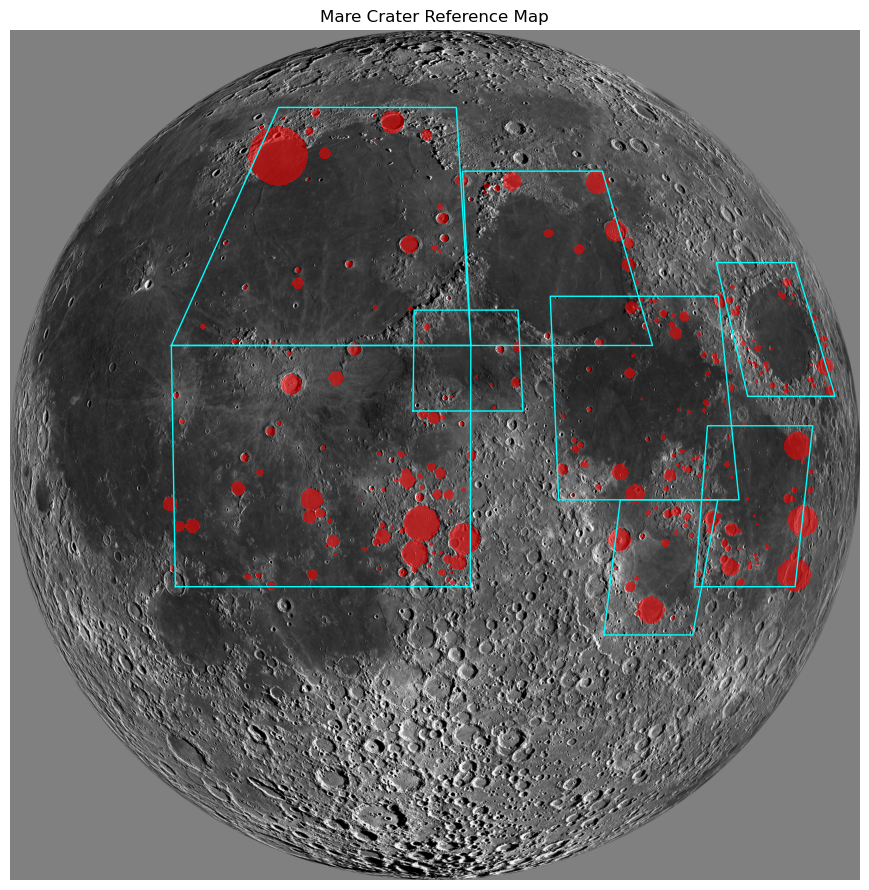

In [6]:
# downsampling for a light figure, the full mask stays in reference_crater_mask
ds = 10

ref_small  = ref_preview
mask_small = reference_crater_mask[::ds, ::ds]


# overlaying the mask and the mare boxes, then saving
plt.figure(figsize = (9, 9))
plt.imshow(ref_small, cmap = 'gray')
plt.imshow(np.ma.masked_where(mask_small == 0, mask_small), cmap = 'autumn', alpha = 0.55)

for lat_lo, lat_hi, lon_lo, lon_hi in maria.values():
    edge_lat = np.array([lat_lo, lat_lo, lat_hi, lat_hi, lat_lo])
    edge_lon = np.array([lon_lo, lon_hi, lon_hi, lon_lo, lon_lo])
    bx, by   = latlon_to_ortho_px(lat_deg = edge_lat, lon_deg = edge_lon)
    plt.plot(bx / ds, by / ds, '-', color = 'cyan', linewidth = 1)

plt.title('Mare Crater Reference Map')
plt.axis('off')
plt.tight_layout()

plt.savefig('lunar_stack_artifacts/crater_reference_map.png', dpi = 120)
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Frame Preprocessing</h2>

The sharpest frame from the provided video is utilized for initial segmentation, based on Laplacian variance. The frame is then reduced to a single grayscale channel to match the reference image. If clips were recorded in landscape, the frame is rotated 90 degrees clockwise for alignment with the crater reference mask.

In [7]:
# lunar clips and which one to align in this pass
clip_dir    = 'lunar_videos'
clip_index  = 0
sample_clip = 'sample_lunar_video.mp4'


# frame selection, 'sharpest' scans the clip for peak focus, or set an explicit frame index
frame_mode  = 'sharpest'
frame_fixed = 0


# non-mp4 containers to normalise into mp4 before anything else runs
convert_exts = {'.avi', '.mov', '.mkv', '.m4v', '.mts', '.m2ts', '.wmv', '.flv', '.webm'}


# putting a clip into an mp4 container, copying the video stream so quality is preserved
def to_mp4(name):
    """Normalises a video in the clip folder to an mp4, preserving quality.

    PARAMETERS
    ----------
    name | str
    a file name inside clip_dir

    EXAMPLES
    --------
    to_mp4(name = 'my_capture.MOV')\
    """

    if shutil.which('ffmpeg') is None:
        raise RuntimeError('ffmpeg is required to convert non-mp4 clips, install it and re-run')

    src_path = os.path.join(clip_dir, name)
    dst_path = os.path.join(clip_dir, os.path.splitext(name)[0] + '.mp4')

    # first pass copies the video stream untouched, the pixels stay bit-for-bit identical
    remux = subprocess.run(['ffmpeg', '-y', '-i', src_path, '-map', '0:v:0', '-c:v', 'copy',
                            '-movflags', '+faststart', dst_path],
                           stdout = subprocess.DEVNULL, stderr = subprocess.DEVNULL)

    # a codec mp4 cannot carry falls back to a lossless rgb re-encode, matching the pipeline's decode
    if remux.returncode != 0 or (not os.path.exists(dst_path)) or os.path.getsize(dst_path) == 0:
        subprocess.run(['ffmpeg', '-y', '-i', src_path, '-map', '0:v:0', '-c:v', 'libx264rgb',
                        '-preset', 'medium', '-crf', '0', '-pix_fmt', 'rgb24', dst_path],
                       stdout = subprocess.DEVNULL, stderr = subprocess.DEVNULL, check = True)

    return dst_path


# looping the folder once, converting every non-mp4 that has no mp4 counterpart yet
folder_files = sorted(os.listdir(clip_dir))
converted    = []

for name in folder_files:
    if os.path.splitext(name)[1].lower() in convert_exts:
        mp4_name = os.path.splitext(name)[0] + '.mp4'
        if mp4_name not in folder_files:
            to_mp4(name = name)
            converted.append((name, mp4_name))

for old_name, new_name in converted:
    print(f'converted {old_name} -> {new_name}')


# the mp4 clips now in the folder, matched on a lowercased name so only 'mp4' is needed
clip_paths = sorted([os.path.join(clip_dir, name) for name in os.listdir(clip_dir)
                     if name.lower().endswith('.mp4')])

if len(clip_paths) == 0:
    raise FileNotFoundError(f'no mp4 clips found in {clip_dir}')


# a user-supplied clip is any mp4 that is not the shipped sample
user_clips = [p for p in clip_paths if os.path.basename(p).lower() != sample_clip]


# a user's own clip runs when present, otherwise the pipeline falls back to the demo sample
if len(user_clips) > 0:
    using_sample = False
    clip_path    = user_clips[clip_index]
else:
    using_sample = True
    clip_path    = os.path.join(clip_dir, sample_clip)


# an 8-bit grayscale view of a colour video frame
def frame_gray(bgr):
    """Reduces a bgr video frame to an 8-bit grayscale frame.

    PARAMETERS
    ----------
    bgr | np.ndarray
    an 8-bit blue-green-red frame from cv2

    EXAMPLES
    --------
    frame_gray(bgr = frame)\
    """

    return cv2.cvtColor(src = bgr, code = cv2.COLOR_BGR2GRAY)


# scanning the clip once for the sharpest frame, laplacian variance as the focus score
best_index = frame_fixed

if frame_mode == 'sharpest':
    scan_capture = cv2.VideoCapture(filename = clip_path)
    best_focus   = -1.0
    frame_index  = 0

    while True:
        ok, bgr = scan_capture.read()
        if not ok:
            break
        focus = cv2.Laplacian(src = frame_gray(bgr = bgr), ddepth = cv2.CV_64F).var()
        if focus > best_focus:
            best_focus = focus
            best_index = frame_index
        frame_index += 1

    scan_capture.release()


# decoding the chosen frame and reducing it to one grayscale channel
read_capture = cv2.VideoCapture(filename = clip_path)
read_capture.set(propId = cv2.CAP_PROP_POS_FRAMES, value = best_index)
ok, bgr = read_capture.read()
read_capture.release()

if not ok:
    raise RuntimeError(f'could not read frame {best_index} from {clip_path}')

moon_raw = frame_gray(bgr = bgr).astype(np.float32)


# rotating a landscape frame a quarter turn clockwise to stand the moon upright
if moon_raw.shape[1] > 1.2 * moon_raw.shape[0]:
    moon_raw = cv2.rotate(moon_raw, cv2.ROTATE_90_CLOCKWISE)


# tenengrad focus measure of the chosen frame, the mean sobel gradient energy
g_x          = cv2.Sobel(src = moon_raw, ddepth = cv2.CV_64F, dx = 1, dy = 0, ksize = 3)
g_y          = cv2.Sobel(src = moon_raw, ddepth = cv2.CV_64F, dx = 0, dy = 1, ksize = 3)
tenengrad_fm = float((g_x**2 + g_y**2).mean())


print(f"""
Test Frame
----------
Clip  : {os.path.basename(clip_path)}
Frame : {best_index}
Shape : {moon_raw.shape[0]} by {moon_raw.shape[1]} px
Tenengrad Focus Measure: {tenengrad_fm}
""")


Test Frame
----------
Clip  : sample_lunar_video.mp4
Frame : 64
Shape : 1920 by 1080 px
Tenengrad Focus Measure: 559.2214081790123



<br>

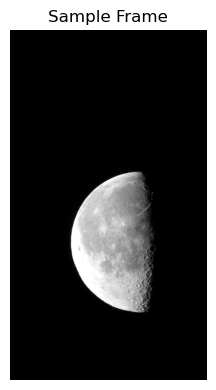

In [8]:
# stretching the linear frame to a visible range using robust percentiles
lo, hi    = np.percentile(moon_raw, q = (1, 99))
moon_disp = np.clip((moon_raw - lo) / (hi - lo), a_min = 0, a_max = 1)


# showing the upright moon in grayscale
plt.figure(figsize = (3, 4))
plt.imshow(moon_disp, cmap = 'gray')
plt.axis('off')
plt.title(label = 'Sample Frame')
plt.tight_layout()
plt.savefig("lunar_stack_artifacts/sample_frame.png")
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Binary Segmentation With SAM</h2>

Binary segmentation was conducted on the test and reference images to separate the Moon from the surrounding dark sky. The base Segment Anything Model (SAM) performed exceptionally well due to the intense contrast between the object of interest and its background. This model, <code>vit_b</code>, contains approximately 91 million parameters, making it the smallest and fastest of Meta's SAM models. During development, <code>vit_b</code> would occasionally over segment the reference image, correctly masking the circular shape of the Moon but leaving a few pinholes on the disk body. To mitigate the risk of over segmentation, a post-segmentation step was implemented to clean each mask by identifying its largest piece and filling any interior holes.
<br>

In [9]:
# downloading the sam vit-b weights on first run, into utilities/models
model_dir       = 'utilities/models'
checkpoint_path = os.path.join(model_dir, 'sam_vit_b_01ec64.pth')

os.makedirs(name = model_dir, exist_ok = True)

if not os.path.exists(checkpoint_path):
    weights_url = 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth'
    urllib.request.urlretrieve(url = weights_url, filename = checkpoint_path)


# attempting to load sam onto the gpu as a predictor
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sam       = sam_model_registry['vit_b'](checkpoint = checkpoint_path)
sam.to(device = device)
predictor = SamPredictor(sam)


def segment_moon_sam(gray, point_xy = None, box_xyxy = None):
    """Segments the lit moon body from a point prompt or a box prompt.

    PARAMETERS
    ----------
    gray | np.ndarray
    single-channel image of the moon on dark sky

    point_xy | tuple
    an (x, y) pixel on the lit disk, or None

    box_xyxy | tuple
    an (x0, y0, x1, y1) box around the disk, or None

    EXAMPLES
    --------
    segment_moon_sam(gray = moon_raw, point_xy = (1800, 1100))\
    """

    h, w      = gray.shape[:2]
    scale     = 1024 / w
    small_rgb = cv2.resize(src   = np.stack([((gray / np.percentile(gray, 99.9)) * 255.0).clip(0, 255).astype(np.uint8)] * 3, axis = -1),
                           dsize = (1024, int(h * scale)))

    point_coords = None
    point_labels = None
    box          = None

    if point_xy is not None:
        point_coords = np.array([[int(point_xy[0] * scale), int(point_xy[1] * scale)]])
        point_labels = np.array([1])

    if box_xyxy is not None:
        box = np.array([box_xyxy[0] * scale, box_xyxy[1] * scale,
                        box_xyxy[2] * scale, box_xyxy[3] * scale])

    amp = torch.cuda.amp.autocast() if device == 'cuda' else contextlib.nullcontext()
    with torch.inference_mode(), amp:
        predictor.set_image(small_rgb)
        masks, scores, _ = predictor.predict(point_coords     = point_coords,
                                             point_labels     = point_labels,
                                             box              = box,
                                             multimask_output = False)

    return cv2.resize(src           = masks[0].astype(np.uint8),
                      dsize         = (w, h),
                      interpolation = cv2.INTER_NEAREST)


# keeping only the largest blob and filling interior holes, to drop specks
def clean_mask(mask):
    """returns the largest connected region of a binary mask with holes filled

    PARAMETERS
    ----------
    mask | np.ndarray
    binary mask that may carry specks or pinholes

    EXAMPLES
    --------
    clean_mask(mask = ref_moon_mask)\
    """

    binary = (mask > 0).astype(np.uint8)

    labelled, count = label(binary)
    if count == 0:
        return binary

    sizes    = np.bincount(labelled.ravel())
    sizes[0] = 0
    largest  = (labelled == sizes.argmax()).astype(np.uint8)

    return binary_fill_holes(largest).astype(np.uint8)


# segmenting then cleaning each moon
bright_ys, bright_xs = np.where(moon_raw > np.percentile(moon_raw, 99))
test_point           = (bright_xs.mean(), bright_ys.mean())

test_moon_mask = clean_mask(segment_moon_sam(gray = moon_raw, point_xy = test_point))


print(f"""
Moon Segments
-------------
test lit  : {test_moon_mask.mean():.1%} of its frame
reference : {ref_moon_mask.mean():.1%} of its frame
""")


Moon Segments
-------------
test lit  : 13.1% of its frame
reference : 77.4% of its frame



<br>

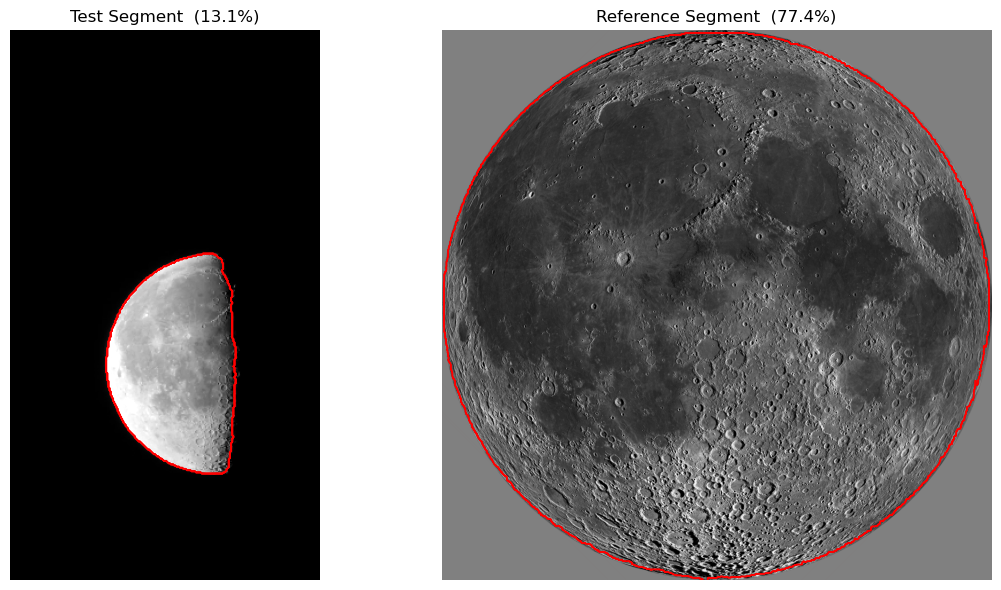

In [10]:
# a quick look at both moon segments
fig, ax = plt.subplots(1, 2, figsize = (12, 6))

ax[0].imshow(moon_raw[::4, ::4], cmap = 'gray', vmax = np.percentile(moon_raw, 99.5))
ax[0].contour(test_moon_mask[::4, ::4], colors = 'red', linewidths = 0.8)
ax[0].set_title(f'Test Segment  ({test_moon_mask.mean():.1%})')
ax[0].axis('off')

ax[1].imshow(ref_preview, cmap = 'gray')
ax[1].contour(ref_moon_mask[::10, ::10], colors = 'red', linewidths = 0.8)
ax[1].set_title(f'Reference Segment  ({ref_moon_mask.mean():.1%})')
ax[1].axis('off')

plt.tight_layout()
plt.savefig("lunar_stack_artifacts/sam_disk_segments.png")
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>RANSAC Circle Fitting</h2>

The circular shape of the outer limb in both segments was estimated with Random Sample Consensus (RANSAC). For each segment, three boundary points were sampled and solved into circles, and the circle the most points agreed with was retained. This helped the RANSAC algorithm ignore points along the terminator, the dividing line that separates the bright and dark portions of the moon. The resulting radius of the RANSAC circle in the reference image was 7,744 pixels, 99.28% the length of the surface radius of the CRS, indicating that the approach was successful. The images can now be scaled to the same size.

In [11]:
# exact circle through three points
def solve_three_point_circle(p1, p2, p3):
    """Returns the centre and radius of the circle through three points.

    PARAMETERS
    ----------
    p1, p2, p3 | tuple
    (x, y) boundary points

    EXAMPLES
    --------
    solve_three_point_circle((0, 0), (1, 0), (0, 1))\
    """

    ax, ay = p1
    bx, by = p2
    cx, cy = p3

    d = 2 * (ax * (by - cy) + bx * (cy - ay) + cx * (ay - by))
    if abs(d) < 1e-6:
        return None

    ux = ((ax**2 + ay**2) * (by - cy) + (bx**2 + by**2) * (cy - ay) + (cx**2 + cy**2) * (ay - by)) / d
    uy = ((ax**2 + ay**2) * (cx - bx) + (bx**2 + by**2) * (ax - cx) + (cx**2 + cy**2) * (bx - ax)) / d

    return ux, uy, math.hypot(ax - ux, ay - uy)


# ransac limb fit on a binary segment
def fit_limb_circle(mask, iterations = 3000, tolerance = 3.0):
    """Fits the full-disk limb circle to a moon segment.

    PARAMETERS
    ----------
    mask | np.ndarray
    binary moon segment

    iterations | int
    number of random three-point trials

    tolerance | float
    inlier band in pixels

    EXAMPLES
    --------
    fit_limb_circle(mask = test_moon_mask)\
    """

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    points      = max(contours, key = cv2.contourArea).reshape(-1, 2).astype(np.float64)

    best_circle  = (0.0, 0.0, 0.0)
    best_inliers = 0

    for _ in range(iterations):
        idx    = np.random.choice(len(points), 3, replace = False)
        result = solve_three_point_circle(points[idx[0]], points[idx[1]], points[idx[2]])
        if result is None:
            continue

        c_x, c_y, rad = result
        if rad <= 0 or rad > max(mask.shape):
            continue

        offsets = np.abs(np.hypot(points[:, 0] - c_x, points[:, 1] - c_y) - rad)
        inliers = int((offsets < tolerance).sum())

        if inliers > best_inliers:
            best_inliers = inliers
            best_circle  = result

    return best_circle, best_inliers


# fitting the limb in both images
np.random.seed(random_seed)

test_circle, test_inliers = fit_limb_circle(mask = test_moon_mask)
ref_circle,  ref_inliers  = fit_limb_circle(mask = ref_moon_mask)


print(f"""
Limb Circles
------------
Test      : Center ({test_circle[0]:.0f}, {test_circle[1]:.0f})  Radius {test_circle[2]:.0f} px  Inliers {test_inliers}
Reference : Center ({ref_circle[0]:.0f}, {ref_circle[1]:.0f})  Radius {ref_circle[2]:.0f} px  Inliers {ref_inliers}
""")


Limb Circles
------------
Test      : Center (719, 1162)  Radius 383 px  Inliers 1136
Reference : Center (7794, 7783)  Radius 7745 px  Inliers 11324



<br>

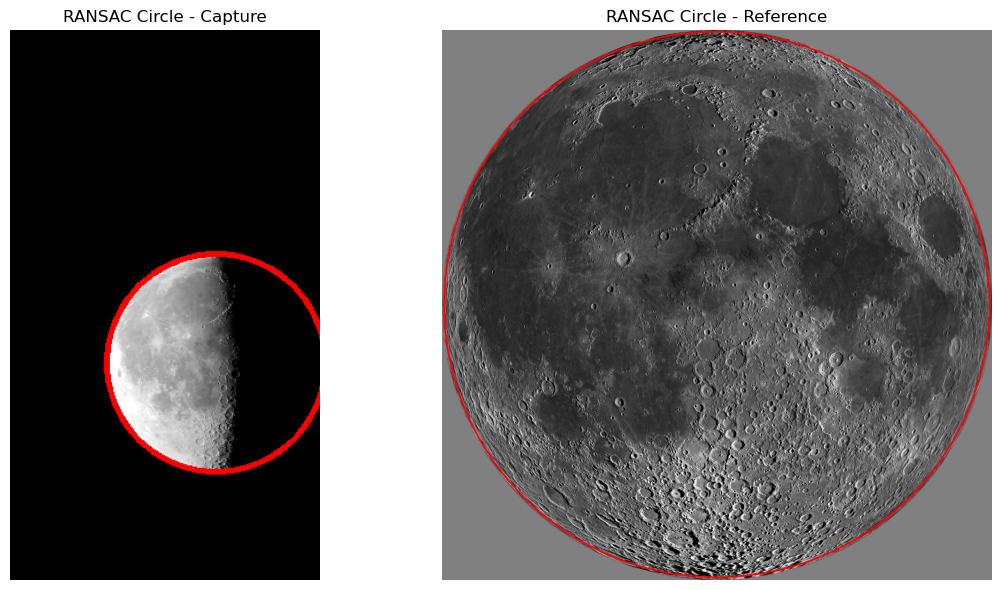

In [12]:
# drawing the fitted limb circle on each frame
test_rgb = np.ascontiguousarray(np.stack([np.clip(moon_raw[::4, ::4] / np.percentile(moon_raw, 99.5), 0, 1)] * 3, axis = -1).astype(np.float32))
cv2.circle(test_rgb, (int(test_circle[0] / 4), int(test_circle[1] / 4)), int(test_circle[2] / 4), (1, 0, 0), 3)

ref_rgb = np.ascontiguousarray(np.stack([np.clip(ref_preview / 255.0, 0, 1)] * 3, axis = -1).astype(np.float32))
cv2.circle(ref_rgb, (int(ref_circle[0] / 10), int(ref_circle[1] / 10)), int(ref_circle[2] / 10), (1, 0, 0), 3)

fig, ax = plt.subplots(1, 2, figsize = (12, 6))
ax[0].imshow(test_rgb); ax[0].set_title('RANSAC Circle - Capture');      ax[0].axis('off')
ax[1].imshow(ref_rgb);  ax[1].set_title('RANSAC Circle - Reference'); ax[1].axis('off')

plt.tight_layout()
plt.savefig("lunar_stack_artifacts/ransac_circles.png")
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Scaling and Translation With RANSAC Circumference</h2>

Utilizing the circumferences of the RANSAC circles, the test frame was resized and translated to align with the reference image. This resulted in the test frame scaling by a factor of 1.425. After reviewing the overlap between the images, initial scaling and translation were both successful and are ready for fine tuning.

In [13]:
# a light square canvas for the overlap work
align_dim = 1200

ref_gray_A   = cv2.resize(src = ref_preview,          dsize = (align_dim, align_dim), interpolation = cv2.INTER_AREA)
ref_moon_A   = cv2.resize(src = ref_moon_mask,         dsize = (align_dim, align_dim), interpolation = cv2.INTER_NEAREST)
ref_crater_A = cv2.resize(src = reference_crater_mask, dsize = (align_dim, align_dim), interpolation = cv2.INTER_NEAREST)


# reference circle re-fitted on the canvas so centre and radius are exact here
np.random.seed(random_seed)
(ref_cx_A, ref_cy_A, ref_R_A), _ = fit_limb_circle(mask = ref_moon_A)


# warping the test so its circle lands on the reference circle
scale_factor = ref_R_A / test_circle[2]

warp = cv2.getRotationMatrix2D(center = (test_circle[0], test_circle[1]), angle = 0, scale = scale_factor)
warp[0, 2] += ref_cx_A - test_circle[0]
warp[1, 2] += ref_cy_A - test_circle[1]

test_gray_A = cv2.warpAffine(src = moon_raw,       M = warp, dsize = (align_dim, align_dim), flags = cv2.INTER_LANCZOS4, borderValue = 0)
test_moon_A = cv2.warpAffine(src = test_moon_mask, M = warp, dsize = (align_dim, align_dim), flags = cv2.INTER_NEAREST,  borderValue = 0)


print(f"""
Scaled to Canvas
----------------
Canvas          : {align_dim} by {align_dim} px
Reference Circle: Center ({ref_cx_A:.0f}, {ref_cy_A:.0f})  Radius {ref_R_A:.0f} px
Scale           : {1 + scale_factor:.3f}
""")


Scaled to Canvas
----------------
Canvas          : 1200 by 1200 px
Reference Circle: Center (600, 598)  Radius 594 px
Scale           : 2.553



<br>

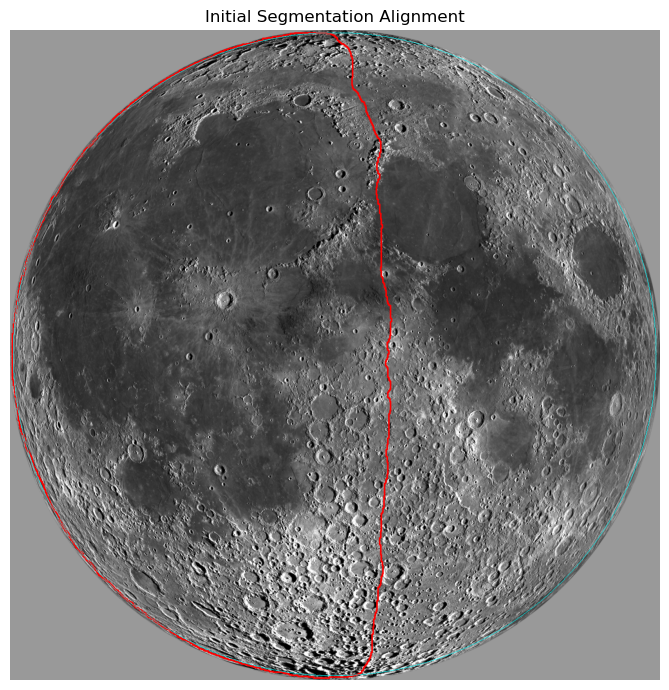

In [14]:
# scaled test outline over the reference disk, with the reference circle in cyan
canvas_rgb = np.ascontiguousarray(np.stack([np.clip(ref_gray_A / np.percentile(ref_gray_A, 99.5), 0, 1)] * 3, axis = -1).astype(np.float32))

contours, _ = cv2.findContours(test_moon_A, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(canvas_rgb, contours, -1, (1, 0, 0), 2)
cv2.circle(canvas_rgb, (int(ref_cx_A), int(ref_cy_A)), int(ref_R_A), (0, 1, 1), 1)

plt.figure(figsize = (7, 7))
plt.imshow(canvas_rgb)
plt.title('Initial Segmentation Alignment')
plt.axis('off')

plt.tight_layout()
plt.savefig("lunar_stack_artifacts/alignment_overlay.png")
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Maximizing Disk Overlap</h2>

A small translation search was conducted to maximize the overlap between the two segments. An overlap of 59% would be ideal given that this was the Moon's illumination level when the test frame was captured. As can be observed from the results, the intersection over union (IoU) metric peaked at a value of 0.580, implying an illumination level of 58% (98.3% of the reference illumination level). There are also very few false positives where the test frame does not overlap with the reference image.

In [15]:
# confusion counts, iou, and dice between two binary masks
def overlap_scores(pred, truth):
    """Scores the overlap of two binary masks.

    PARAMETERS
    ----------
    pred | np.ndarray
    predicted binary mask

    truth | np.ndarray
    reference binary mask

    EXAMPLES
    --------
    overlap_scores(pred = test_moon_A, truth = ref_moon_A)\
    """

    pred  = pred.astype(bool)
    truth = truth.astype(bool)

    tp = int(( pred &  truth).sum())
    fp = int(( pred & ~truth).sum())
    fn = int((~pred &  truth).sum())
    tn = int((~pred & ~truth).sum())

    iou  = tp / (tp + fp + fn)         if (tp + fp + fn)     else 0.0
    dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0.0

    return (tp, fp, fn, tn), iou, dice


# small translation search to maximise the disk overlap
best_shift = (0, 0)
best_iou   = -1.0

for shift_y in range(-8, 9, 2):
    for shift_x in range(-8, 9, 2):
        shifted   = np.roll(np.roll(test_moon_A, shift_y, axis = 0), shift_x, axis = 1)
        _, iou, _ = overlap_scores(pred = shifted, truth = ref_moon_A)
        if iou > best_iou:
            best_iou   = iou
            best_shift = (shift_x, shift_y)


# applying the best shift to the test grayscale and mask
shift_x, shift_y = best_shift
test_gray_A = np.roll(np.roll(test_gray_A, shift_y, axis = 0), shift_x, axis = 1)
test_moon_A = np.roll(np.roll(test_moon_A, shift_y, axis = 0), shift_x, axis = 1)

(tp, fp, fn, tn), disk_iou, disk_dice = overlap_scores(pred = test_moon_A, truth = ref_moon_A)


print(f"""
Disk Overlap
------------
Shift: dx {shift_x}, dy {shift_y}

Mask Overlap                (tp): {tp:>9}
Background Overlap          (tn): {tn:>9}
Test Frame Non-Overlap      (fp): {fp:>9}
Reference Image Non-Overlap (fn): {fn:>9}

IoU : {disk_iou:.3f}
DICE: {disk_dice:.3f}
""")


Disk Overlap
------------
Shift: dx 8, dy 0

Mask Overlap                (tp):    652245
Background Overlap          (tn):    325692
Test Frame Non-Overlap      (fp):       332
Reference Image Non-Overlap (fn):    461731

IoU : 0.585
DICE: 0.738



<br>

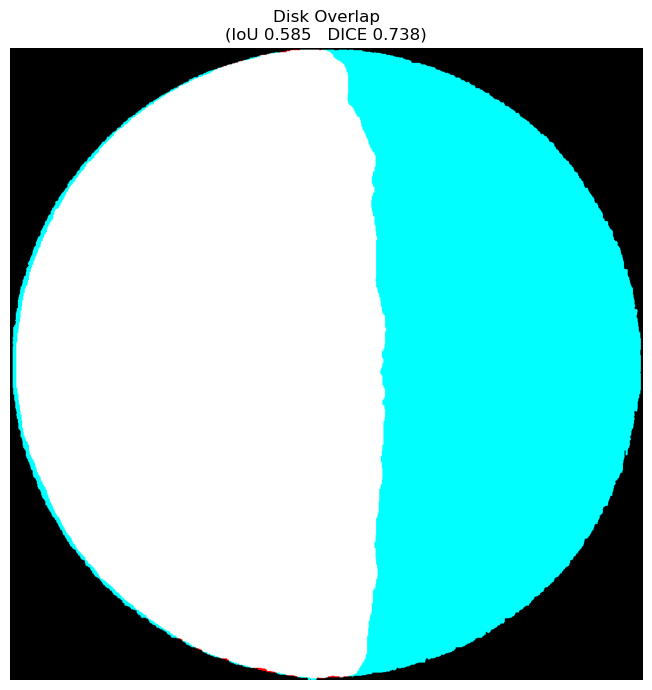

In [16]:
# red is the test disk, cyan is the reference disk, grey is agreement
composite = np.zeros((align_dim, align_dim, 3), dtype = np.float32)
composite[..., 0] = test_moon_A
composite[..., 1] = ref_moon_A
composite[..., 2] = ref_moon_A

plt.figure(figsize = (7, 7))
plt.imshow(composite)
plt.title(f"""Disk Overlap
(IoU {disk_iou:.3f}   DICE {disk_dice:.3f})""")
plt.axis('off')
plt.tight_layout()

plt.savefig("lunar_stack_artifacts/disk_overlap.png")
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Centroid-Based Crater Alignment</h2>

Scale and translation have been addressed, leaving only rotation as a factor to align the images further. Thus, craters will be detected in the test segment using a non-buffered Laplacian-of-Gaussian blob detector (LoG) and evaluated against the crater reference mask. LoG is an advanced computer vision algorithm originally designed to predict circular structures, making it a strong candidate for this task. Additionally, four hyperparameters were engineered to control the number of craters being utilized for alignment, crater diameter minimums and maximums, and the crater magnification level.
<br><br>

| Hyperparameter | Description |
| --- | --- |
| `n_closest` | How many of the nearest detected craters to keep. |
| `min_diameter` | Smallest crater size allowed (in pixels). |
| `max_diameter` | Largest crater size allowed (in pixels). |
| `magnification` | Scaling factor (zoom level) applied to the view or measurements. |

<br>

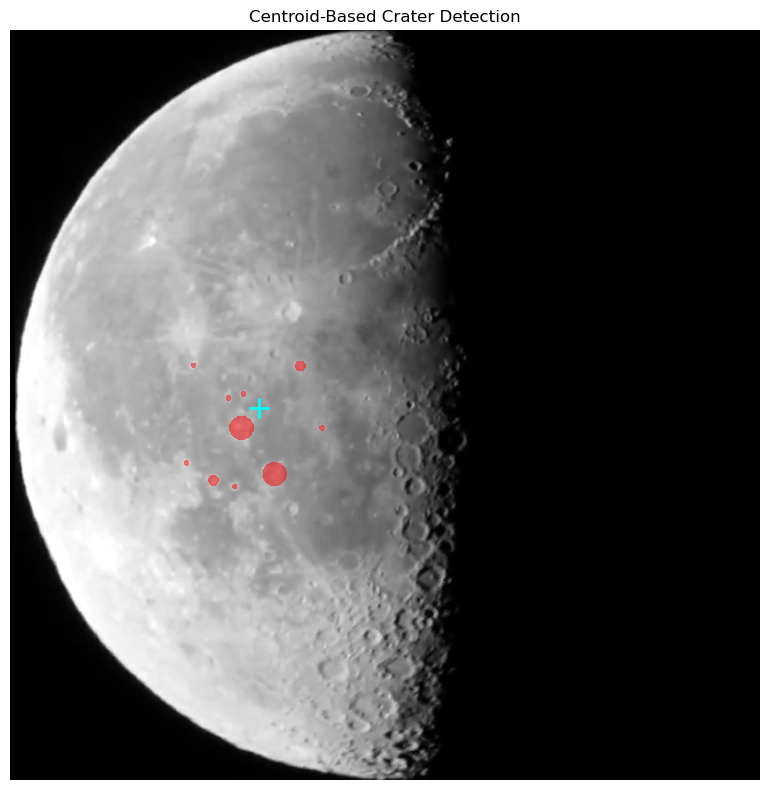

 detected_ID    lat    lon  diam_km
           0   2.10  -2.63    38.02
           1  -3.11  -2.98   123.99
           2   1.52  -5.15    38.02
           3   6.44   6.53    59.52
           4  -3.11  10.03    38.02
           5 -10.30   2.18   123.99
           6   6.54 -11.45    38.02
           7 -12.27  -4.74    38.02
           8 -11.29  -8.37    59.52
           9  -8.54 -12.97    38.02


In [17]:
# how many nearest craters, the diameter band, and the draw magnification
n_closest     = 10
min_diameter  = 0.0
max_diameter  = 303.0
magnification = 1.0


# a canvas pixel to selenographic latitude and longitude, through the reference circle
def canvas_px_to_latlon(u, v):
    """maps a canvas pixel to latitude and longitude on the reference disk

    PARAMETERS
    ----------
    u, v | float
    pixel column and row on the alignment canvas

    EXAMPLES
    --------
    canvas_px_to_latlon(u = 600, v = 600)\
    """

    x = u - ref_cx_A
    y = ref_cy_A - v

    lat = math.degrees(math.asin(max(-1.0, min(1.0, y / ref_R_A))))
    lon = math.degrees(math.atan2(x, math.sqrt(max(0.0, ref_R_A**2 - x**2 - y**2))))

    return lat, lon


# detecting every crater in the segment, no buffer
test_norm = np.clip(test_gray_A / (np.percentile(test_gray_A, 99.5) + 1e-6), 0, 1)
test_8u   = cv2.bitwise_and((test_norm * 255).astype(np.uint8),
                            (test_norm * 255).astype(np.uint8),
                            mask = test_moon_A)

blobs = blob_log(test_8u.astype(np.float32) / 255.0,
                 min_sigma = 2,
                 max_sigma = 15,
                 num_sigma = 6,
                 threshold = 0.06)


# the centroid of the segment
moments    = cv2.moments(test_moon_A)
centroid_x = moments['m10'] / moments['m00']
centroid_y = moments['m01'] / moments['m00']
cen_lat, cen_lon = canvas_px_to_latlon(u = centroid_x, v = centroid_y)


# every detection, with its true diameter and its distance to the centroid
km_per_px_A = 1737.4 / ref_R_A

records = []
for b_y, b_x, b_sigma in blobs:
    b_r      = b_sigma * math.sqrt(2)
    lat, lon = canvas_px_to_latlon(u = b_x, v = b_y)
    records.append({'x_px'      : float(b_x),
                    'y_px'      : float(b_y),
                    'r_base_px' : float(b_r),
                    'lat'       : lat - cen_lat,
                    'lon'       : lon - cen_lon,
                    'diam_km'   : 2.0 * b_r * km_per_px_A,
                    'dist'      : math.hypot(b_x - centroid_x, b_y - centroid_y)})

all_detections = pd.DataFrame(records)


# applying the four controls: diameter band, then nearest-n, then a magnified draw radius
def build_detected(n_keep, min_km, max_km, magnify):
    """Selects and sizes detections from the four hyperparameters.

    PARAMETERS
    ----------
    n_keep | int
    how many nearest-to-centroid detections to keep

    min_km, max_km | float
    diameter band in kilometres

    magnify | float
    multiplier on each crater's drawn radius

    EXAMPLES
    --------
    build_detected(n_keep = 10, min_km = 0, max_km = 300, magnify = 2)\
    """

    kept = all_detections[(all_detections['diam_km'] >= min_km) &
                          (all_detections['diam_km'] <= max_km)].copy()
    kept = kept.sort_values('dist').head(n_keep).reset_index(drop = True)
    kept['r_px'] = kept['r_base_px'] * magnify
    kept.insert(0, 'detected_ID', kept.index)

    return kept[['detected_ID', 'x_px', 'y_px', 'r_px', 'lat', 'lon', 'diam_km']]


# painting a crater dataframe into a binary mask on the canvas
def craters_to_mask(frame):
    """Paints a crater dataframe into a binary mask on the canvas.

    PARAMETERS
    ----------
    frame | pd.DataFrame
    craters with x_px, y_px, r_px columns

    EXAMPLES
    --------
    craters_to_mask(frame = detected_craters)\
    """

    mask = np.zeros((align_dim, align_dim), dtype = np.uint8)
    for _, crater in frame.iterrows():
        cv2.circle(img       = mask,
                   center    = (int(crater['x_px']), int(crater['y_px'])),
                   radius    = max(2, int(crater['r_px'])),
                   color     = 1,
                   thickness = -1)
    return (mask & test_moon_A).astype(np.uint8)


detected_craters = build_detected(n_keep = n_closest, min_km = min_diameter, max_km = max_diameter, magnify = magnification)
test_crater_mask = craters_to_mask(frame = detected_craters)


# a stable snapshot of the centroid-step detections, used later during review
centroid_craters = detected_craters.copy()


# plotting the centroid and the kept craters, then saving
plt.figure(figsize = (8, 8))
plt.imshow(test_norm, cmap = 'gray')
plt.imshow(np.ma.masked_where(test_crater_mask == 0, test_crater_mask), cmap = 'autumn', alpha = 0.5)
plt.scatter([centroid_x], [centroid_y], marker = '+', s = 220, c = 'cyan', linewidths = 2)
plt.title(f'Centroid-Based Crater Detection')
plt.axis('off')

plt.tight_layout()
plt.savefig('lunar_stack_artifacts/centroid_based_crater_detection.png', dpi = 120)
plt.show()

print(detected_craters[['detected_ID', 'lat', 'lon', 'diam_km']].round(2).to_string(index = False))

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Tuning Crater Alignment</h2>

The crater selection was tuned with a Bayesian search that maximized the DICE coefficient. Repeated runs placed the diameter band, magnification, and draw radius in close agreement, so those three controls were fixed and only the number of nearest craters was searched. Each candidate set was scored by shifting the detected craters across the disk, up, down, left, right, or diagonally, paired with a small rotation window that absorbs residual field rotation. The selected configuration is reported in the output below.


In [18]:
# hyperparameter tuning, three controls fixed by agreement, only the crater count is searched
n_closest_grid     = np.arange(2, 6, 1)
min_diameter_grid  = np.array([30])
max_diameter_grid  = np.array([200])
magnification_grid = np.array([2.0])
tuning_trials      = 10


# projecting the mare catalog craters onto the canvas, the alignment target
def canvas_latlon_to_px(lat_deg, lon_deg):
    """Maps latitude and longitude to a canvas pixel on the reference disk.

    PARAMETERS
    ----------
    lat_deg, lon_deg | float
    latitude north and longitude east, in degrees

    EXAMPLES
    --------
    canvas_latlon_to_px(lat_deg = 9.62, lon_deg = -20.07)\
    """

    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)

    return ref_cx_A + ref_R_A * np.cos(lat) * np.sin(lon), ref_cy_A - ref_R_A * np.sin(lat)


catalog_u, catalog_v = canvas_latlon_to_px(lat_deg = visible['lat'].values, lon_deg = visible['lon'].values)
catalog_r            = np.maximum(2.0, (visible['diam_km'].values / 2.0) / km_per_px_A)


# painting equal disks, reference sized to match its test crater, so the score reflects position
def crater_disks(x_values, y_values, r_values):
    """Paints craters as filled disks on the canvas.

    PARAMETERS
    ----------
    x_values, y_values, r_values | iterable
    centres and radii in canvas pixels

    EXAMPLES
    --------
    crater_disks([600], [600], [10])\
    """

    mask = np.zeros((align_dim, align_dim), dtype = np.uint8)
    for x_c, y_c, r_c in zip(x_values, y_values, r_values):
        cv2.circle(img = mask, center = (int(x_c), int(y_c)), radius = max(2, int(r_c)), color = 1, thickness = -1)
    return mask


# matching a crater set to the catalog under a shift and a small rotation, then the best crater DICE
def align_score(craters, trans_range = 40.0, trans_step = 4.0, rot_range = 1.5, rot_step = 0.5, fixed_angle = None):
    """Matches detected craters to the catalog under a shift and a small rotation.

    PARAMETERS
    ----------
    craters | pd.DataFrame
    detected craters with x_px, y_px, r_px columns

    trans_range | float
    half-width of the translation search in pixels

    trans_step | float
    translation step in pixels

    rot_range | float
    half-width of the rotation window in degrees

    rot_step | float
    rotation step in degrees

    EXAMPLES
    --------
    align_score(craters = detected_craters, trans_step = 1.0)\
    """

    blank = np.zeros((align_dim, align_dim), dtype = np.uint8)

    if len(craters) < 2:
        return {'n_matched': 0, 'init_iou': 0.0, 'init_dice': 0.0, 'opt_iou': 0.0,
                'opt_dice': 0.0, 'best_dx': 0.0, 'best_dy': 0.0, 'best_angle': 0.0,
                'test_mask': blank, 'ref_mask': blank, 'test_rot': blank}

    test_r = craters['r_px'].values
    base_x = craters['x_px'].values
    base_y = craters['y_px'].values


    # shifting the crater centres by a translation and a small rotation about the disk centre
    def transform_points(dx, dy, angle):
        theta = math.radians(angle)
        off_x = base_x - ref_cx_A
        off_y = base_y - ref_cy_A
        px    = ref_cx_A + off_x * math.cos(theta) - off_y * math.sin(theta) + dx
        py    = ref_cy_A + off_x * math.sin(theta) + off_y * math.cos(theta) + dy
        return px, py


    # matching every moved crater to its nearest unused catalog crater, then the disk dice
    def score_at(dx, dy, angle):
        px, py  = transform_points(dx = dx, dy = dy, angle = angle)
        taken   = set()
        test_cx = []; test_cy = []; test_cr = []
        ref_cx  = []; ref_cy  = []; ref_cr  = []

        for k in range(len(px)):
            gaps  = np.hypot(catalog_u - px[k], catalog_v - py[k])
            order = np.argsort(gaps)

            nearest = -1
            for j in order:
                if int(j) not in taken:
                    nearest = int(j)
                    break

            if nearest < 0:
                continue

            taken.add(nearest)
            test_cx.append(px[k]);             test_cy.append(py[k]);             test_cr.append(test_r[k])
            ref_cx.append(catalog_u[nearest]); ref_cy.append(catalog_v[nearest]); ref_cr.append(test_r[k])

        if len(test_cx) < 2:
            return 0.0, 0.0, blank, blank, 0

        test_mask = crater_disks(test_cx, test_cy, test_cr)
        ref_mask  = crater_disks(ref_cx,  ref_cy,  ref_cr)
        _, iou, dice = overlap_scores(pred = test_mask, truth = ref_mask)

        return iou, dice, test_mask, ref_mask, len(test_cx)


    # the un-shifted baseline, then the strongest shift and angle across the search grid
    init_iou, init_dice, init_test, init_ref, init_n = score_at(dx = 0.0, dy = 0.0, angle = 0.0)

    best_dx    = 0.0
    best_dy    = 0.0
    best_angle = 0.0
    best_iou   = init_iou
    best_dice  = init_dice
    best_test  = init_test
    best_ref   = init_ref
    best_n     = init_n

    # a pinned rotation skips the angle sweep, otherwise search the small rotation window
    angle_grid = np.array([fixed_angle]) if fixed_angle is not None else np.arange(-rot_range, rot_range + rot_step, rot_step)

    for dx in np.arange(-trans_range, trans_range + trans_step, trans_step):
        for dy in np.arange(-trans_range, trans_range + trans_step, trans_step):
            for angle in angle_grid:
                iou, dice, test_mask, ref_mask, n_at = score_at(dx = dx, dy = dy, angle = angle)
                if dice > best_dice:
                    best_dx    = dx
                    best_dy    = dy
                    best_angle = angle
                    best_iou   = iou
                    best_dice  = dice
                    best_test  = test_mask
                    best_ref   = ref_mask
                    best_n     = n_at

    return {'n_matched': best_n, 'init_iou': init_iou, 'init_dice': init_dice, 'opt_iou': best_iou,
            'opt_dice': best_dice, 'best_dx': best_dx, 'best_dy': best_dy, 'best_angle': best_angle,
            'test_mask': init_test, 'ref_mask': best_ref, 'test_rot': best_test}


# one optuna trial: sample the crater count, build that set, and return its best DICE
def objective(trial):
    """Scores one hyperparameter draw by its best crater DICE.

    PARAMETERS
    ----------
    trial | optuna.Trial
    the trial that proposes the crater count

    EXAMPLES
    --------
    study.optimize(objective, n_trials = 100)\
    """

    n_keep  = trial.suggest_int(name = 'n_closest',    low = int(n_closest_grid.min()),    high = int(n_closest_grid.max()))
    min_km  = trial.suggest_int(name = 'min_diameter', low = int(min_diameter_grid.min()), high = int(min_diameter_grid.max()), step = 10)
    max_km  = trial.suggest_int(name = 'max_diameter', low = int(max_diameter_grid.min()), high = int(max_diameter_grid.max()), step = 10)
    magnify = trial.suggest_float(name = 'magnification', low = round(float(magnification_grid.min()), 2), high = round(float(magnification_grid.max()), 2), step = 0.1)

    # skipping configurations already evaluated, returning the earlier score
    for prior in trial.study.trials:
        if prior.state == optuna.trial.TrialState.COMPLETE and prior.params == trial.params:
            return prior.value

    if min_km >= max_km:
        return 0.0

    trial_craters = build_detected(n_keep = n_keep, min_km = min_km, max_km = max_km, magnify = magnify)
    return align_score(craters = trial_craters)['opt_dice']


# the sample clip adopts its known-best configuration, a user clip is tuned with optuna
if using_sample:
    # optimal configuration for the shipped sample clip, tuning skipped
    n_closest     = 2
    min_diameter  = 30.0
    max_diameter  = 200.0
    magnification = 2.0

    study = None
    best  = None

else:
    # running the study quietly and reproducibly
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    study = optuna.create_study(direction = 'maximize',
                                sampler   = optuna.samplers.TPESampler(seed = random_seed))
    study.optimize(objective, n_trials = tuning_trials, show_progress_bar = False)


    # ranking every trial by dice, then breaking ties by fewest craters, then tightest floor
    ranked = study.trials_dataframe(attrs = ('value', 'params'))
    ranked = ranked.sort_values(by        = ['value', 'params_n_closest', 'params_min_diameter'],
                                ascending = [False,    True,               False]).reset_index(drop = True)


    # keeping one row per unique configuration
    ranked = ranked.drop_duplicates(subset = ['params_n_closest',
                                              'params_min_diameter',
                                              'params_max_diameter',
                                              'params_magnification']).reset_index(drop = True)


    # adopting the best row
    best          = ranked.iloc[0]
    n_closest     = int(best['params_n_closest'])
    min_diameter  = float(best['params_min_diameter'])
    max_diameter  = float(best['params_max_diameter'])
    magnification = float(best['params_magnification'])


# rebuilding the detections with the adopted configuration
detected_craters = build_detected(n_keep = n_closest, min_km = min_diameter, max_km = max_diameter, magnify = magnification)
test_crater_mask = craters_to_mask(frame = detected_craters)


# a stable snapshot of the tuning-step detections, used later during review
tuned_craters = detected_craters.copy()


if using_sample:
    print(f"""
Optuna Tuning
-------------
Trials       : skipped (sample clip)
n_closest    : {n_closest}
min_diameter : {min_diameter:.0f} km
max_diameter : {max_diameter:.0f} km
magnification: {magnification:.1f}
""")

else:
    print(f"""
Optuna Tuning
-------------
Trials       : {len(study.trials)}
Best DICE    : {best['value']:.3f}
n_closest    : {n_closest}
min_diameter : {min_diameter:.0f} km
max_diameter : {max_diameter:.0f} km
magnification: {magnification:.1f}
""")

    # the strongest trials, ties broken by fewest craters then tightest floor
    print(ranked.head(n = 10).to_string(index = False))


Optuna Tuning
-------------
Trials       : skipped (sample clip)
n_closest    : 2
min_diameter : 30 km
max_diameter : 200 km
magnification: 2.0



<br>

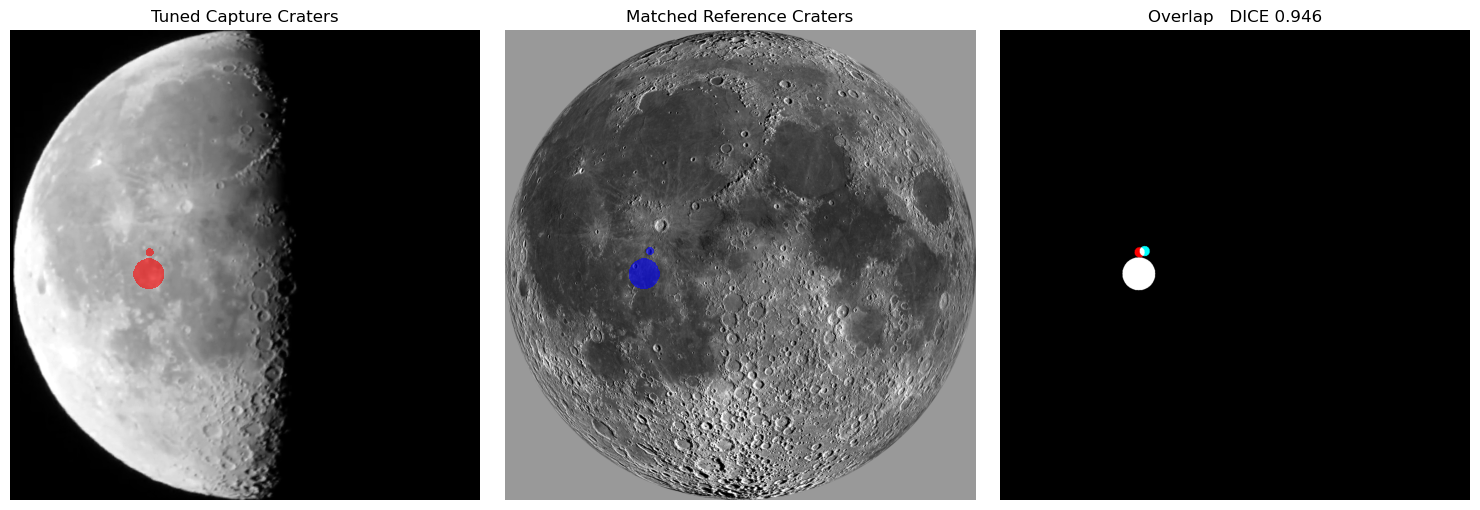

In [19]:
# the best tuning configuration scored and rotated for display
tuned_result   = align_score(craters = detected_craters)
test_norm_disp = np.clip(test_gray_A / (np.percentile(test_gray_A, 99.5) + 1e-6), 0, 1)
ref_norm_disp  = np.clip(ref_gray_A  / (np.percentile(ref_gray_A,  99.5) + 1e-6), 0, 1)


# tuned test craters, matched reference craters, and their overlap at the best shift
fig, ax = plt.subplots(1, 3, figsize = (15, 5))

ax[0].imshow(test_norm_disp, cmap = 'gray')
ax[0].imshow(np.ma.masked_where(tuned_result['test_rot'] == 0, tuned_result['test_rot']), cmap = 'autumn', alpha = 0.6)
ax[0].set_title('Tuned Capture Craters'); ax[0].axis('off')

ax[1].imshow(ref_norm_disp, cmap = 'gray')
ax[1].imshow(np.ma.masked_where(tuned_result['ref_mask'] == 0, tuned_result['ref_mask']), cmap = 'winter', alpha = 0.6)
ax[1].set_title('Matched Reference Craters'); ax[1].axis('off')

overlap = np.zeros((align_dim, align_dim, 3), dtype = np.float32)
overlap[..., 0] = tuned_result['test_rot']
overlap[..., 1] = tuned_result['ref_mask']
overlap[..., 2] = tuned_result['ref_mask']
ax[2].imshow(overlap); ax[2].set_title(f"Overlap   DICE {tuned_result['opt_dice']:.3f}"); ax[2].axis('off')

plt.tight_layout()
plt.savefig('lunar_stack_artifacts/tuning_best_alignment.png', dpi = 120)
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Removing False Positives</h2>

False positives can be filtered out manually. Doing so will rewrite the set detected craters and rebuild the crater mask.

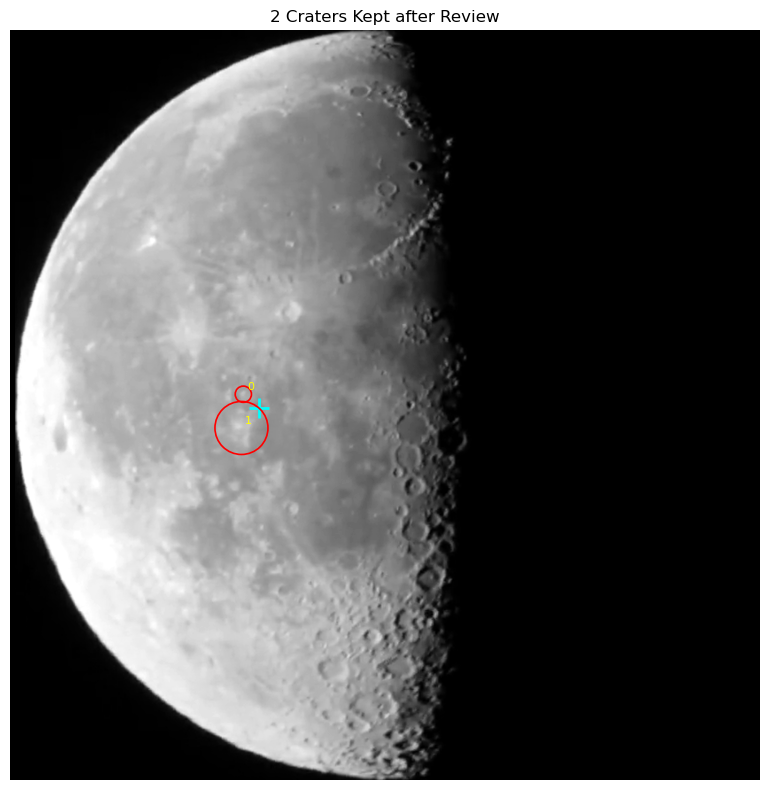


Reviewed Craters
----------------
Dropped: []
Kept   : 2



In [20]:
# detected_ID values to treat as false positives, edit and re-run to iterate
false_positive_ids = []


# the craters detected in the centroid step or the tuning step, keyed by canvas position
detected_universe = pd.concat([centroid_craters, tuned_craters], ignore_index = True)
detected_keys     = set(zip(detected_universe['x_px'].round(3), detected_universe['y_px'].round(3)))


# reviewing the stable tuning-step detections, keeping only genuine detections, then dropping the flagged ids
craters_reviewed = tuned_craters.copy()
craters_reviewed = craters_reviewed[[(x, y) in detected_keys
                                     for x, y in zip(craters_reviewed['x_px'].round(3),
                                                     craters_reviewed['y_px'].round(3))]].reset_index(drop = True)
craters_reviewed = craters_reviewed[~craters_reviewed['detected_ID'].isin(false_positive_ids)].reset_index(drop = True)


# visualising the kept craters with their ids so they can be fine tuned
plt.figure(figsize = (8, 8))
plt.imshow(test_norm, cmap = 'gray')
plt.scatter([centroid_x], [centroid_y], marker = '+', s = 220, c = 'cyan', linewidths = 2)

for _, crater in craters_reviewed.iterrows():
    circle = plt.Circle((crater['x_px'], crater['y_px']), max(3, crater['r_px']),
                        color = 'red', fill = False, linewidth = 1.2)
    plt.gca().add_patch(circle)
    plt.text(crater['x_px'] + 6, crater['y_px'] - 6, str(int(crater['detected_ID'])),
             color = 'yellow', fontsize = 8)

plt.title(f'{len(craters_reviewed)} Craters Kept after Review')
plt.axis('off')
plt.tight_layout()
plt.savefig('lunar_stack_artifacts/moon_segment_crater_predictions.png', dpi = 120)
plt.show()


# saving back under the original name and rebuilding the mask for the pipeline
detected_craters = craters_reviewed
test_crater_mask = craters_to_mask(frame = detected_craters)

print(f"""
Reviewed Craters
----------------
Dropped: {false_positive_ids}
Kept   : {len(detected_craters)}
""")

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Matching Craters and Optimizing DICE</h2>

With scale and centre already fixed, the final match is a fine search over translation and a small rotation window. The best shift, the best angle, and their DICE coefficient are reported in the output below.


In [21]:
# final matched alignment on the tuned and reviewed craters, using a fine translation and rotation step
# the sample clip pins rotation to its known-best 0.10 deg, a user clip searches the rotation window
if using_sample:
    result = align_score(craters = detected_craters, trans_step = 1.0, fixed_angle = 0.10)
else:
    result = align_score(craters = detected_craters, trans_step = 1.0, rot_step = 0.1)
ref_norm = np.clip(ref_gray_A / (np.percentile(ref_gray_A, 99.5) + 1e-6), 0, 1).astype(np.float32)


print(f"""
Crater Overlap
--------------
Matched  : {result['n_matched']}
Shift    : ({result['best_dx']:.0f}, {result['best_dy']:.0f}) px
Rotation : {result['best_angle']:.2f} deg
              Initial   Optimised
IoU      : {result['init_iou']:>8.3f}   {result['opt_iou']:>8.3f}
DICE     : {result['init_dice']:>8.3f}   {result['opt_dice']:>8.3f}
""")


Crater Overlap
--------------
Matched  : 2
Shift    : (-15, -13) px
Rotation : 0.10 deg
              Initial   Optimised
IoU      :    0.501      0.908
DICE     :    0.668      0.952



<br>

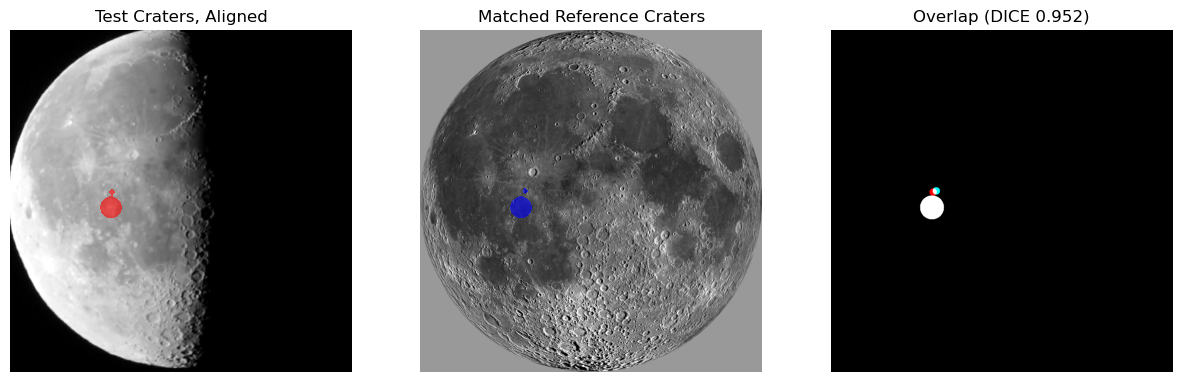

In [22]:
# applying the solved shift and small rotation to the aligned frame
warp         = cv2.getRotationMatrix2D(center = (ref_cx_A, ref_cy_A), angle = result['best_angle'], scale = 1.0)
warp[0, 2]  += result['best_dx']
warp[1, 2]  += result['best_dy']
test_aligned = cv2.warpAffine(test_gray_A, warp, (align_dim, align_dim), flags = cv2.INTER_LANCZOS4)

test_aligned_norm = np.clip(test_aligned / (np.percentile(test_aligned, 99.5) + 1e-6), 0, 1)


# side by side and overlap, after the alignment
fig, ax = plt.subplots(1, 3, figsize = (15, 5))

ax[0].imshow(test_aligned_norm, cmap = 'gray')
ax[0].imshow(np.ma.masked_where(result['test_rot'] == 0, result['test_rot']), cmap = 'autumn', alpha = 0.6)
ax[0].set_title('Test Craters, Aligned'); ax[0].axis('off')

ax[1].imshow(ref_norm, cmap = 'gray')
ax[1].imshow(np.ma.masked_where(result['ref_mask'] == 0, result['ref_mask']), cmap = 'winter', alpha = 0.6)
ax[1].set_title('Matched Reference Craters'); ax[1].axis('off')

overlap = np.zeros((align_dim, align_dim, 3), dtype = np.float32)
overlap[..., 0] = result['test_rot']
overlap[..., 1] = result['ref_mask']
overlap[..., 2] = result['ref_mask']
ax[2].imshow(overlap); ax[2].set_title(f'Overlap (DICE {result["opt_dice"]:.3f})'); ax[2].axis('off')

#plt.tight_layout()
plt.savefig("lunar_stack_artifacts/final_crater_alignment.png")
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Aligned Frame Export</h2>

Each frame is aligned on its own and then refined onto a shared reference with sub-pixel phase correlation, so the Moon holds a fixed position and neither drifts nor jumps across the clip. The lit disk is located and centred onto one padded reference circle at a single fixed scale, since the moon's size is constant within a clip, and the orientation solved during crater matching is applied. The sub-pixel refinement falls back to the geometric centre whenever it asks for a shift past the margin, so a correlation misfire cannot throw the disk out of frame. As each frame is written it is scored for focus, through the Tenengrad gradient energy, and for disk overlap, through IoU and DICE against the first aligned frame. The per-frame table is saved as <code>frame_stack.csv</code>. Frames export as 16-bit TIF, colour by default so a colour composite can be built later, and the folder is compressed for download.


In [23]:
# where the aligned frames and the archive are written
clip_stem = os.path.splitext(os.path.basename(clip_path))[0]
frame_dir = 'aligned_frames'
zip_stem  = 'aligned_frames'

os.makedirs(name = frame_dir, exist_ok = True)


# colour keeps the full rgb for a colour composite, grayscale keeps the luminance only
color_output = True


# a padded target circle on the canvas, the margin keeps the limb inside every frame
pad_factor = 0.85
target_R   = ref_R_A * pad_factor
ref_raw_R  = test_circle[2]


# one fixed scale from the reliable reference radius, the moon's size is constant within a clip
disk_scale = target_R / ref_raw_R


# the largest residual shift phase correlation may apply, beyond this it is treated as a misfire
max_shift  = 0.20 * target_R


# the constant orientation from crater matching, rotated about the disk centre
orient_warp   = cv2.getRotationMatrix2D(center = (ref_cx_A, ref_cy_A), angle = result['best_angle'], scale = 1.0)
orient_affine = np.vstack([orient_warp, [0, 0, 1]])


# a hann window steadies the phase correlation against the frame edges
hann = cv2.createHanningWindow(winSize = (align_dim, align_dim), type = cv2.CV_32F)


# the min-enclosing limb circle of a frame's lit disk, fast enough to run per frame
def frame_limb(gray_u8):
    """Fits a limb circle to one video frame from its lit disk.

    PARAMETERS
    ----------
    gray_u8 | np.ndarray
    an 8-bit grayscale frame

    EXAMPLES
    --------
    frame_limb(gray_u8 = gray)\
    """

    _, disk = cv2.threshold(src = gray_u8, thresh = 0, maxval = 1, type = cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    disk    = clean_mask(mask = disk)

    contours, _ = cv2.findContours(disk, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return None

    (c_x, c_y), rad = cv2.minEnclosingCircle(max(contours, key = cv2.contourArea))
    return c_x, c_y, rad


# focus as the mean sobel gradient energy inside a mask
def tenengrad(gray, mask):
    """Scores focus as the mean sobel gradient energy inside a mask.

    PARAMETERS
    ----------
    gray | np.ndarray
    single-channel image

    mask | np.ndarray
    binary region to score within

    EXAMPLES
    --------
    tenengrad(gray = luma, mask = template_disk)\
    """

    g_x    = cv2.Sobel(src = gray, ddepth = cv2.CV_64F, dx = 1, dy = 0, ksize = 3)
    g_y    = cv2.Sobel(src = gray, ddepth = cv2.CV_64F, dx = 0, dy = 1, ksize = 3)
    energy = g_x**2 + g_y**2
    return float(energy[mask > 0].mean())


# picking the fastest lossless tiff codec available, zstd when present, otherwise zlib
def pick_tif_codec():
    """Returns imwrite kwargs for the fastest available lossless tiff codec."""

    probe = os.path.join(frame_dir, '.codec_probe.tif')
    try:
        tiff.imwrite(probe, np.zeros((4, 4), dtype = np.uint16), compression = 'zstd', compressionargs = {'level': 1})
        return {'compression': 'zstd', 'compressionargs': {'level': 1}}
    except Exception:
        return {'compression': 'zlib'}
    finally:
        if os.path.exists(probe):
            os.remove(probe)

tif_kwargs = pick_tif_codec()


# aligning every frame, refining onto a shared reference, then scoring and writing it
export_capture = cv2.VideoCapture(filename = clip_path)
reference_luma = None
template_disk  = None
records        = []
clamped        = 0
frame_index    = 0

while True:
    ok, bgr = export_capture.read()
    if not ok:
        break

    if color_output:
        image = cv2.cvtColor(src = bgr, code = cv2.COLOR_BGR2RGB).astype(np.float32)
    else:
        image = frame_gray(bgr = bgr).astype(np.float32)

    if image.shape[1] > 1.2 * image.shape[0]:
        image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)

    gray = image if image.ndim == 2 else image.mean(axis = 2)


    # locating this frame's disk, recording a skip when the limb cannot be fit
    limb = frame_limb(gray_u8 = np.clip(gray, 0, 255).astype(np.uint8))

    if limb is None or not (0.6 * ref_raw_R < limb[2] < 1.4 * ref_raw_R):
        records.append({'frame_index': frame_index, 'kept': False, 'aligned_path': None,
                        'tenengrad': np.nan, 'iou': np.nan, 'dice': np.nan, 'log_dice': np.nan})
        frame_index += 1
        continue


    # scaling and centring this frame's disk onto the padded reference circle
    c_x, c_y, rad = limb

    frame_warp        = cv2.getRotationMatrix2D(center = (c_x, c_y), angle = 0, scale = disk_scale)
    frame_warp[0, 2] += ref_cx_A - c_x
    frame_warp[1, 2] += ref_cy_A - c_y

    coarse_affine = orient_affine @ np.vstack([frame_warp, [0, 0, 1]])


    # refining onto the first kept frame with sub-pixel phase correlation, so the disk does not jump
    # this warp only feeds the correlation, so bilinear is enough, the final output warp keeps lanczos
    coarse_luma = cv2.warpAffine(gray, coarse_affine[:2, :], (align_dim, align_dim), flags = cv2.INTER_LINEAR, borderValue = 0)

    if reference_luma is None:
        reference_luma   = coarse_luma.astype(np.float32)
        shift_x, shift_y = 0.0, 0.0
    else:
        (shift_x, shift_y), _ = cv2.phaseCorrelate(src1 = reference_luma, src2 = coarse_luma.astype(np.float32), window = hann)

        # a shift past the margin is a correlation misfire, falling back to the geometric centre
        if math.hypot(shift_x, shift_y) > max_shift:
            shift_x, shift_y = 0.0, 0.0
            clamped         += 1

    refine_affine = np.array([[1, 0, -shift_x], [0, 1, -shift_y], [0, 0, 1]], dtype = np.float64)
    full_warp     = (refine_affine @ coarse_affine)[:2, :]


    # the final aligned frame, its luma, and the disk it produced
    aligned = cv2.warpAffine(image, full_warp, (align_dim, align_dim), flags = cv2.INTER_LANCZOS4, borderValue = 0)
    luma    = aligned if aligned.ndim == 2 else aligned.mean(axis = 2)

    _, disk = cv2.threshold(src = np.clip(luma, 0, 255).astype(np.uint8), thresh = 0, maxval = 1, type = cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # the first kept frame's disk is the alignment template, illumination is constant within a clip
    if template_disk is None:
        template_disk = disk


    # per-frame focus and disk-overlap scores, measured against the template
    _, iou, dice = overlap_scores(pred = disk, truth = template_disk)
    log_dice     = float(-np.log10(1.0 - dice + 1e-6))
    focus        = tenengrad(gray = luma, mask = template_disk)


    # writing the aligned frame as a 16-bit tif
    aligned16    = (np.clip(aligned, 0, 255) * 257).astype(np.uint16)
    aligned_path = os.path.join(frame_dir, f'{clip_stem}_aligned_{frame_index:06d}.tif')

    tiff.imwrite(aligned_path, aligned16, **tif_kwargs)

    records.append({'frame_index': frame_index, 'kept': True, 'aligned_path': aligned_path,
                    'tenengrad': focus, 'iou': iou, 'dice': dice, 'log_dice': log_dice})
    frame_index += 1

export_capture.release()


# the per-frame table, a sharpness percentile over every scored frame, saved to the working directory
frame_stack               = pd.DataFrame(data = records)
frame_stack['percentile'] = frame_stack['tenengrad'].rank(pct = True) * 100

frame_stack.to_csv(path_or_buf = 'frame_stack.csv', index = False)


# an optional download bundle, off by default since nothing below reads it
make_archive = False

# storing without recompression, the tiffs are already compressed so deflate would only waste time
archive_path = None
if make_archive:
    archive_path = f'{zip_stem}.zip'
    with zipfile.ZipFile(archive_path, mode = 'w', compression = zipfile.ZIP_STORED) as bundle:
        for name in sorted(os.listdir(frame_dir)):
            bundle.write(filename = os.path.join(frame_dir, name), arcname = name)


print(f"""
Aligned Frame Export
--------------------
Clip    : {os.path.basename(clip_path)}
Mode    : {'colour rgb' if color_output else 'grayscale'}
Kept    : {int(frame_stack['kept'].sum())}
Skipped : {int((~frame_stack['kept']).sum())}
Refined : {int(frame_stack['kept'].sum()) - clamped} locked, {clamped} fell back to centre
Table   : frame_stack.csv
Archive : {archive_path if archive_path else 'skipped, set make_archive = True to write one'}
""")


Aligned Frame Export
--------------------
Clip    : sample_lunar_video.mp4
Mode    : colour rgb
Kept    : 551
Skipped : 0
Refined : 248 locked, 303 fell back to centre
Table   : frame_stack.csv
Archive : skipped, set make_archive = True to write one



<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Frame Quality</h2>

Every scored frame is reviewed before stacking. The two curves below read straight off <code>frame_stack</code>, one for focus and one for alignment, and the gallery samples aligned frames across the sharpness range so the disk can be checked for a steady position.


In [24]:
# a wrapped italic caption beneath a figure
def add_caption(fig, text, width = 120):
    """Writes a wrapped italic caption beneath a figure.

    PARAMETERS
    ----------
    fig | matplotlib.figure.Figure
    the figure to caption

    text | str
    the caption text

    EXAMPLES
    --------
    add_caption(fig = fig, text = 'a short note')\
    """

    fig.text(x = 0.5, y = -0.02, s = textwrap.fill(text = text, width = width),
             ha = 'center', va = 'top', fontsize = 10, style = 'italic', color = '#333')


# a robust percentile stretch for viewing only, colour or grayscale, the saved data is untouched
def stretch(image_16bit):
    """Applies a robust percentile stretch to an image for viewing only.

    PARAMETERS
    ----------
    image_16bit | np.ndarray
    a 16-bit image to display

    EXAMPLES
    --------
    stretch(image_16bit = mean_16)\
    """

    img    = image_16bit.astype(np.float32)
    lo, hi = np.percentile(img, 0.5), np.percentile(img, 99.5)
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h3>Sorted Tenengrad Distribution</h3>

The focus score of every kept frame, sorted sharpest first, with the top 10, 25, and 50 percent cutoffs marked.


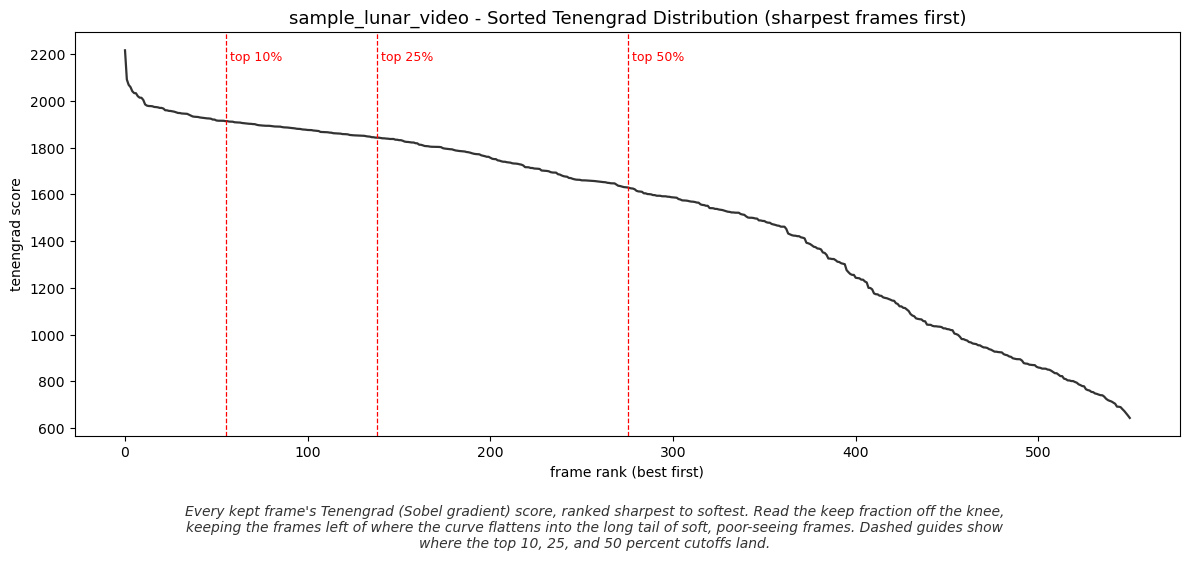

In [25]:
# the sharpness curve, sorted best first, with candidate keep cutoffs
sorted_ten = frame_stack['tenengrad'].dropna().sort_values(ascending = False).reset_index(drop = True)
cutoffs    = [0.10, 0.25, 0.50]

fig, axis = plt.subplots(figsize = (12, 5))
axis.plot(sorted_ten.index, sorted_ten.values, color = '#333', linewidth = 1.6)

for cutoff in cutoffs:
    x = cutoff * len(sorted_ten)
    axis.axvline(x = x, color = 'red', linestyle = '--', linewidth = 0.9)
    axis.text(x = x, y = sorted_ten.max(), s = f' top {int(cutoff*100)}%', color = 'red',
              va = 'top', fontsize = 9)

axis.set_title(label = f'{clip_stem} - Sorted Tenengrad Distribution (sharpest frames first)', fontsize = 13)
axis.set_xlabel(xlabel = 'frame rank (best first)')
axis.set_ylabel(ylabel = 'tenengrad score')

add_caption(fig, "Every kept frame's Tenengrad (Sobel gradient) score, ranked sharpest to softest. Read the keep fraction off the knee, keeping the frames left of where the curve flattens into the long tail of soft, poor-seeing frames. Dashed guides show where the top 10, 25, and 50 percent cutoffs land.")

plt.tight_layout()
plt.savefig(fname = f'lunar_stack_artifacts/{clip_stem}_eda_tenengrad_sorted.png', dpi = 150, bbox_inches = 'tight')
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h3>Sorted Alignment Overlap</h3>

The disk-overlap DICE of every kept frame, mapped through <code>log_dice</code> to spread the crowded high end, sorted best first, with a candidate floor.


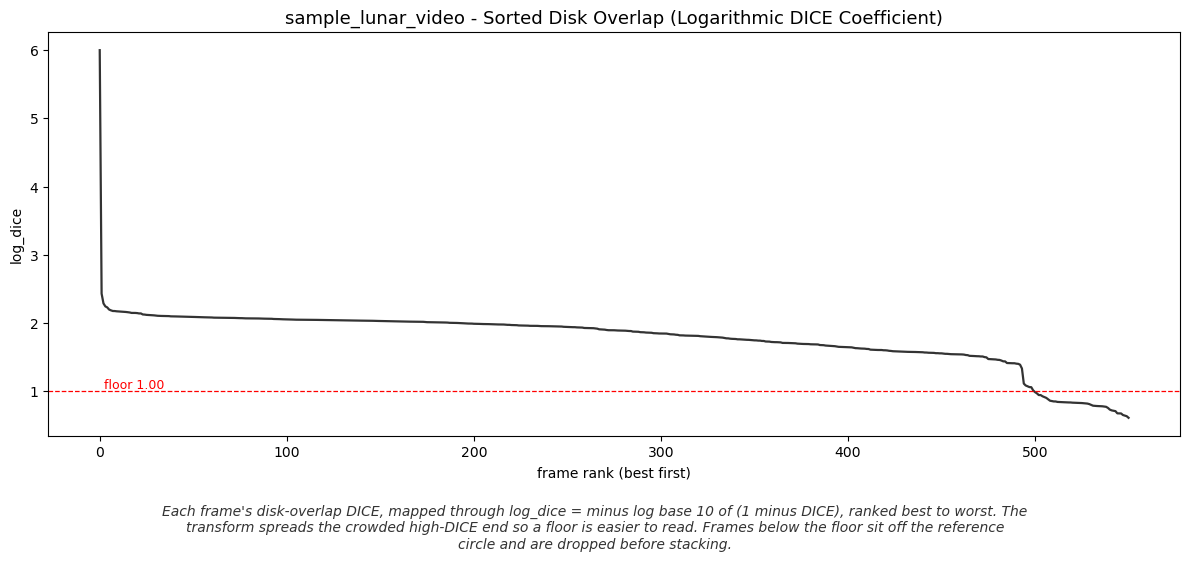

In [26]:
# the alignment-quality curve, sorted best first, with a candidate floor
sorted_dice     = frame_stack['log_dice'].dropna().sort_values(ascending = False).reset_index(drop = True)
log_dice_marker = 1.00

fig, axis = plt.subplots(figsize = (12, 5))
axis.plot(sorted_dice.index, sorted_dice.values, color = '#333', linewidth = 1.6)

axis.axhline(y = log_dice_marker, color = 'red', linestyle = '--', linewidth = 0.9)
axis.text(x = 0, y = log_dice_marker, s = f' floor {log_dice_marker:.2f}', color = 'red',
          va = 'bottom', fontsize = 9)

axis.set_title(label = f'{clip_stem} - Sorted Disk Overlap (Logarithmic DICE Coefficient)', fontsize = 13)
axis.set_xlabel(xlabel = 'frame rank (best first)')
axis.set_ylabel(ylabel = 'log_dice')

add_caption(fig, "Each frame's disk-overlap DICE, mapped through log_dice = minus log base 10 of (1 minus DICE), ranked best to worst. The transform spreads the crowded high-DICE end so a floor is easier to read. Frames below the floor sit off the reference circle and are dropped before stacking.")

plt.tight_layout()
plt.savefig(fname = f'lunar_stack_artifacts/{clip_stem}_eda_log_dice_sorted.png', dpi = 150, bbox_inches = 'tight')
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h3>Percentile Frame Gallery</h3>

An aligned frame drawn near each sharpness percentile. The disk should hold the same position and size across every panel.


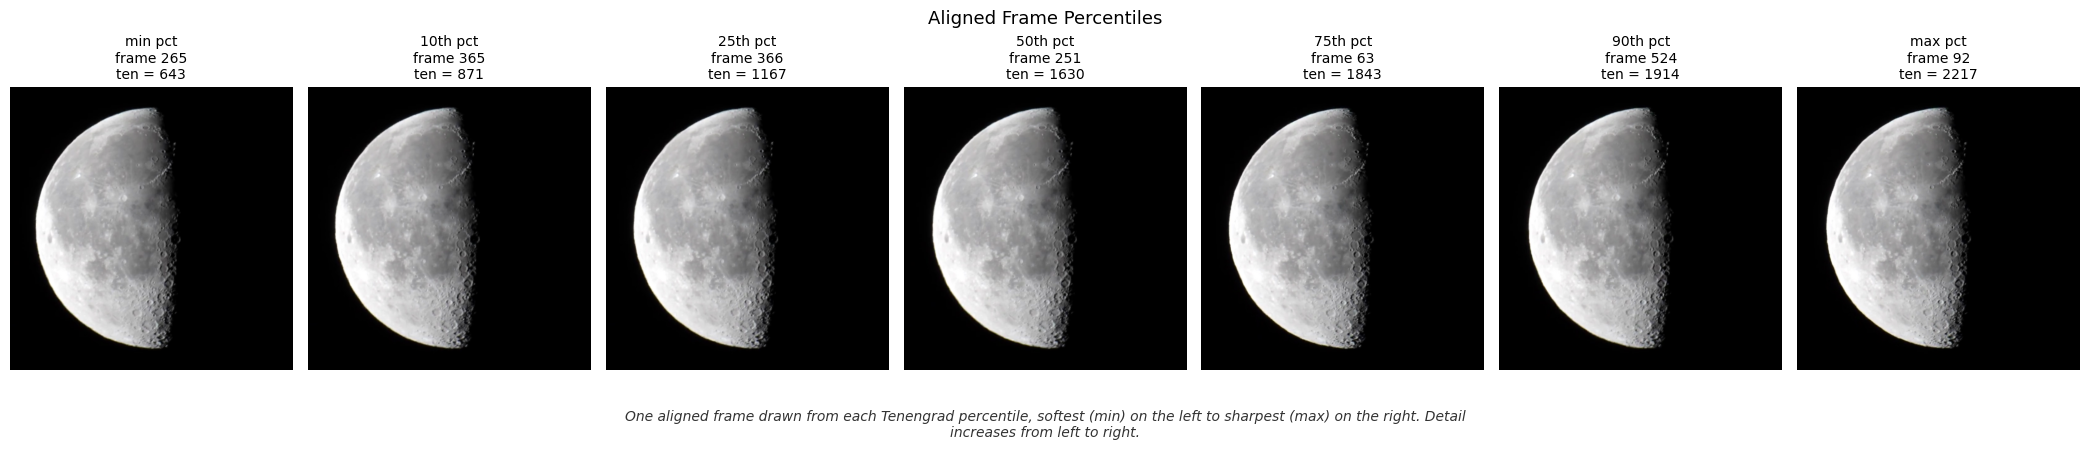

In [27]:
# the aligned frame nearest each requested sharpness percentile
gallery_percentiles = [0, 10, 25, 50, 75, 90, 100]

kept_frames  = frame_stack[frame_stack['kept']]
gallery_rows = [(kept_frames['percentile'] - p).abs().idxmin() for p in gallery_percentiles]

fig, panels = plt.subplots(nrows = 1, ncols = len(gallery_percentiles), figsize = (3 * len(gallery_percentiles), 4))

for panel, pct, row in zip(panels, gallery_percentiles, gallery_rows):
    fidx  = int(frame_stack.loc[row, 'frame_index'])
    score = frame_stack.loc[row, 'tenengrad']
    label = {0: 'min', 100: 'max'}.get(pct, f'{pct}th')
    panel.imshow(X = stretch(image_16bit = tiff.imread(frame_stack.loc[row, 'aligned_path'])))
    panel.set_title(label = f'{label} pct\nframe {fidx}\nten = {score:.0f}', fontsize = 10)
    panel.axis('off')

fig.suptitle(t = f'Aligned Frame Percentiles', fontsize = 13)

add_caption(fig, "One aligned frame drawn from each Tenengrad percentile, softest (min) on the left to sharpest (max) on the right. Detail increases from left to right.")

plt.tight_layout(rect = [0, 0, 1, 0.95])
plt.savefig(fname = f'lunar_stack_artifacts/{clip_stem}_eda_percentile_gallery.png', dpi = 150, bbox_inches = 'tight')
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<br><h2>Lucky Imaging Stacks</h2>

The aligned frames share one coordinate system and are already locked to a common reference, so stacking averages away sensor noise and atmospheric wobble while steady detail reinforces. Selection follows the lucky-imaging idea directly: keep the sharpest frames by Tenengrad and drop any whose alignment <code>log_dice</code> fell below a floor. Two stacks are written, a <strong>mean</strong> for the smoothest noise and a <strong>median</strong> over a capped subset that rejects transient artefacts such as satellite trails. The mean streams over every kept frame while the median holds its subset in memory, so it is capped.


In [28]:
# where the stacks are written
stack_dir = 'stacks'
os.makedirs(name = stack_dir, exist_ok = True)


# selection: how many of the sharpest frames to stack, the alignment floor, and the median cap
stack_sharpest = 30 #100
log_dice_floor = 1.95 #0.30
median_max     = 30 #50


# the kept, well-aligned frames, sharpest first, capped at the sharpest n
stackable = frame_stack[frame_stack['aligned_path'].notna() &
                        (frame_stack['log_dice'] >= log_dice_floor)].copy()
stackable = stackable.sort_values(by = 'tenengrad', ascending = False).head(n = stack_sharpest).reset_index(drop = True)

if len(stackable) == 0:
    raise ValueError('no frames passed log_dice_floor, lower it using the sorted log_dice curve above')


# a streaming mean over every kept frame, with a capped cube held back for the median
sample      = tiff.imread(stackable['aligned_path'].iloc[0]).astype(np.float64)
accumulator = np.zeros_like(sample)
median_cube = []
used        = 0

for _, row in tqdm(stackable.iterrows(), total = len(stackable), desc = 'stacking frames'):
    frame = tiff.imread(row['aligned_path']).astype(np.float64)

    accumulator += frame
    if len(median_cube) < median_max:
        median_cube.append(frame)
    used += 1


# the mean stack over all kept frames and the median stack over the capped subset
mean_16   = np.clip(accumulator / max(1, used),                    0, 65535).astype(np.uint16)
median_16 = np.clip(np.median(np.stack(median_cube, axis = 0), 0), 0, 65535).astype(np.uint16)

mean_path   = os.path.join(stack_dir, f'{clip_stem}_stack_mean.tif')
median_path = os.path.join(stack_dir, f'{clip_stem}_stack_median.tif')

tiff.imwrite(mean_path,   mean_16,   compression = 'zlib')
tiff.imwrite(median_path, median_16, compression = 'zlib')


print(f"""
Lucky Imaging Stack
-------------------
Available  : {int(frame_stack['kept'].sum())} kept frames
Sharpness  : top {stack_sharpest} by tenengrad
DICE floor : log_dice >= {log_dice_floor}
Stacked    : {used} frames
Median     : {min(used, median_max)} frames
Mean stack : {mean_path}
Median     : {median_path}
""")

stacking frames: 100%|██████████████████████████| 30/30 [00:00<00:00, 62.31it/s]



Lucky Imaging Stack
-------------------
Available  : 551 kept frames
Sharpness  : top 30 by tenengrad
DICE floor : log_dice >= 1.95
Stacked    : 30 frames
Median     : 30 frames
Mean stack : stacks/sample_lunar_video_stack_mean.tif
Median     : stacks/sample_lunar_video_stack_median.tif



<br>

A look at the two stacks, percentile-stretched for viewing.


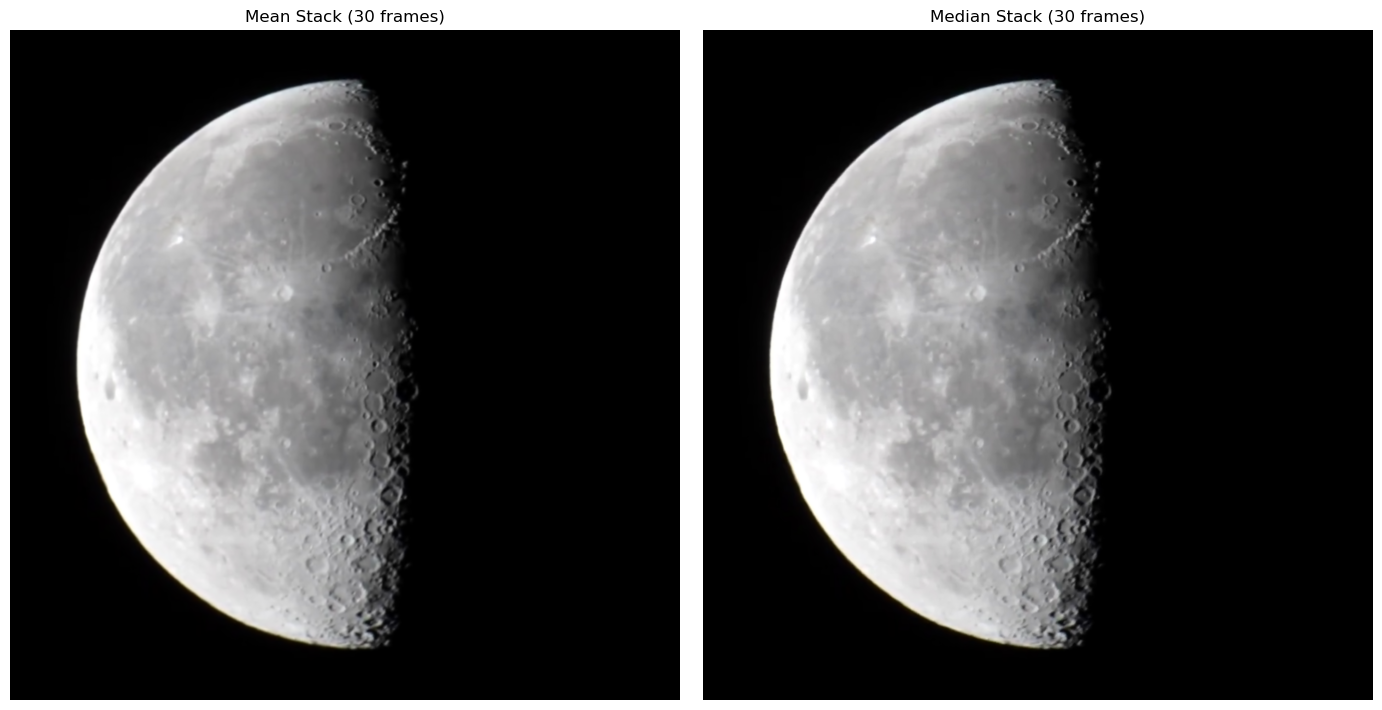

In [29]:
# mean beside median, stretched for viewing only
fig, ax = plt.subplots(1, 2, figsize = (14, 7))

ax[0].imshow(X = stretch(image_16bit = mean_16))
ax[0].set_title(label = f'Mean Stack ({used} frames)'); ax[0].axis('off')

ax[1].imshow(X = stretch(image_16bit = median_16))
ax[1].set_title(label = f'Median Stack ({min(used, median_max)} frames)'); ax[1].axis('off')

plt.tight_layout()
plt.savefig(fname = f'{stack_dir}/{clip_stem}_stack_preview.png', dpi = 150, bbox_inches = 'tight')
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<br><h2>Grayscale Stacks</h2>

In [30]:
# grayscale 16-bit mean and median stacks over the sharpest, well-aligned frames
stack_dir      = 'stacks'
stack_count    = 30
log_dice_floor = 1.95

os.makedirs(name = stack_dir, exist_ok = True)


# the sharpest frames that cleared the alignment floor
chosen = frame_stack[frame_stack['aligned_path'].notna() &
                     (frame_stack['log_dice'] >= log_dice_floor)].copy()
chosen = chosen.sort_values(by = 'tenengrad', ascending = False).head(n = stack_count).reset_index(drop = True)

if len(chosen) == 0:
    raise ValueError('no frames cleared log_dice_floor, lower it using the sorted log_dice curve')


# reading each aligned frame as a single luminance channel
cube = []

for path in chosen['aligned_path']:
    frame = tiff.imread(path).astype(np.float64)
    luma  = frame if frame.ndim == 2 else frame.mean(axis = 2)
    cube.append(luma)

cube = np.stack(cube, axis = 0)


# the mean and median stacks, both over the same frames
mean_16   = np.clip(cube.mean(axis = 0),       0, 65535).astype(np.uint16)
median_16 = np.clip(np.median(cube, axis = 0), 0, 65535).astype(np.uint16)

mean_path   = os.path.join(stack_dir, f'{clip_stem}_stack_mean_gray.tif')
median_path = os.path.join(stack_dir, f'{clip_stem}_stack_median_gray.tif')

tiff.imwrite(mean_path,   mean_16,   compression = 'zlib')
tiff.imwrite(median_path, median_16, compression = 'zlib')


print(f"""
Grayscale Stacks
----------------
Frames : {len(chosen)}
Floor  : log_dice >= {log_dice_floor}
Mean   : {mean_path}
Median : {median_path}
""")


Grayscale Stacks
----------------
Frames : 30
Floor  : log_dice >= 1.95
Mean   : stacks/sample_lunar_video_stack_mean_gray.tif
Median : stacks/sample_lunar_video_stack_median_gray.tif



<br>

A look at the two grayscale stacks, percentile-stretched for viewing.

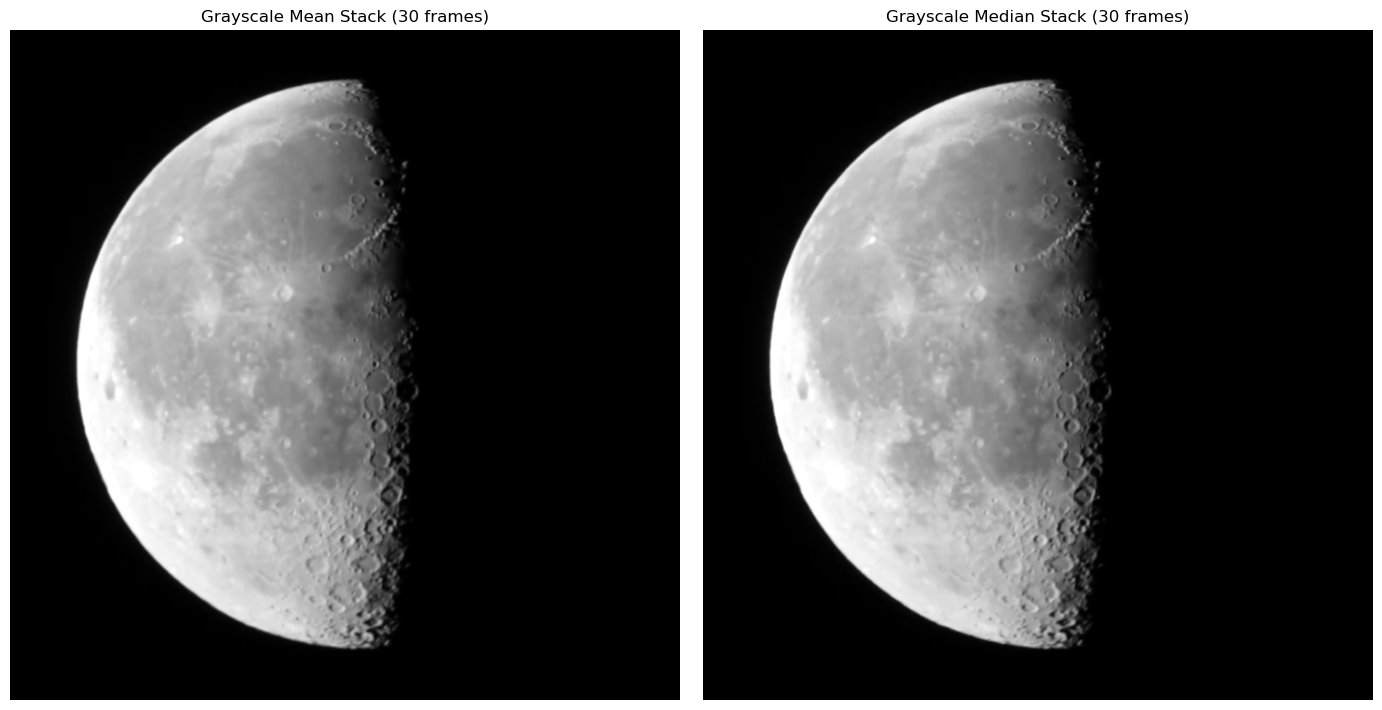

In [31]:
# grayscale mean beside median, stretched for viewing only
fig, ax = plt.subplots(1, 2, figsize = (14, 7))

ax[0].imshow(X = stretch(image_16bit = mean_16), cmap = 'gray')
ax[0].set_title(label = f'Grayscale Mean Stack ({len(chosen)} frames)'); ax[0].axis('off')

ax[1].imshow(X = stretch(image_16bit = median_16), cmap = 'gray')
ax[1].set_title(label = f'Grayscale Median Stack ({len(chosen)} frames)'); ax[1].axis('off')

plt.tight_layout()
plt.savefig(fname = f'{stack_dir}/{clip_stem}_stack_gray_preview.png', dpi = 150, bbox_inches = 'tight')
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Sharpness Comparison</h2>

A closing look at focus scores for the sharpest single frame and the four stacks.

In [32]:
# a closing sharpness comparison, the sharpest single frame against the four stacks
# each image is reduced to a 0-255 luma so the scores share the per-frame basis used above
# scipy's label and hole-fill are re-imported privately, an earlier cell rebinds the name 'label'
from scipy.ndimage import label as _sp_label, binary_fill_holes as _sp_fill


def to_luma_255(img):
    """Reduces an image to a single 0-255 luminance channel."""
    luma = img.astype(np.float64)
    luma = luma if luma.ndim == 2 else luma.mean(axis = 2)
    return luma / 257.0 if img.dtype == np.uint16 else luma


def disk_of(gray_255):
    """Otsu-thresholds the lit disk of a 0-255 luma, cleaned to one filled region."""
    gray_u8 = np.clip(gray_255, 0, 255).astype(np.uint8)
    _, mask = cv2.threshold(src = gray_u8, thresh = 0, maxval = 1, type = cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    binary          = (mask > 0).astype(np.uint8)
    labelled, count = _sp_label(binary)
    if count == 0:
        return binary

    sizes    = np.bincount(labelled.ravel())
    sizes[0] = 0
    largest  = (labelled == sizes.argmax()).astype(np.uint8)
    return _sp_fill(largest).astype(np.uint8)


def laplacian_focus(gray_255, mask):
    """Variance of the Laplacian response inside a mask."""
    lap = cv2.Laplacian(src = gray_255, ddepth = cv2.CV_64F)
    return float(lap[mask > 0].var())


# reading the four stacks back from disk, beside the sharpest original frame held in memory
color_mean   = tiff.imread(os.path.join(stack_dir, f'{clip_stem}_stack_mean.tif'))
color_median = tiff.imread(os.path.join(stack_dir, f'{clip_stem}_stack_median.tif'))
gray_mean    = tiff.imread(os.path.join(stack_dir, f'{clip_stem}_stack_mean_gray.tif'))
gray_median  = tiff.imread(os.path.join(stack_dir, f'{clip_stem}_stack_median_gray.tif'))

catalog = [('Mean Stack (color)',       color_mean),
           ('Median Stack (color)',     color_median),
           ('Mean Stack (grayscale)',   gray_mean),
           ('Median Stack (grayscale)', gray_median)]


# tenengrad and laplacian per image, and a percentile against the per-frame tenengrad spread
frame_scores = frame_stack['tenengrad'].dropna().values

rows = []
for title, image in catalog:
    luma = to_luma_255(img = image)
    disk = disk_of(gray_255 = luma)
    ten  = tenengrad(gray = luma, mask = disk)
    lap  = laplacian_focus(gray_255 = luma, mask = disk)
    pct  = float((frame_scores <= ten).mean() * 100.0)
    rows.append({'Image': title, 'Tenengrad': ten, 'Laplacian': lap, 'Percentile': pct})


# the comparison, sharpest tenengrad first, rounded to two decimals for display
sharpness_summary = (pd.DataFrame(data = rows)
                       .sort_values(by = 'Tenengrad', ascending = False)
                       .round({'Tenengrad': 2, 'Laplacian': 2, 'Percentile': 2})
                       .set_index('Image'))

# checking results
sharpness_summary

,Tenengrad,Laplacian,Percentile
Image,,,
Median Stack (grayscale),1703.82,8.33,58.62
Median Stack (color),1703.55,8.13,58.62
Mean Stack (grayscale),1572.96,5.13,43.92
Mean Stack (color),1572.83,5.13,43.92


<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Conclusion</h2>

Astrophotography comes with a steep learning curve spanning several steps, including camera/telescope configuration, celestial object detection, capturing focused and stable frames, frame alignment, lucky imaging, and post-processing techniques such as wavelet sharpening. Frame alignment is the first step post-capture step, and this project has introduced a highly automated pipeline specifically designed for aligning frames of the Moon. The pipeline advances beyond existing techniques such as global stabilization and automatic grandient-based local alignment based on image gradients, utilizing modern computer vision techniques such as SAM and LoG in a practical manner.
<br><br>
A future project is being considered for lucky imaging and wavelet sharpening, expanding the post-capture pipeline into an end-to-end solution so that astrophotographers can focus their efforts on detecting and capturing celestial objects.

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />